# Table of Contents

- [Imports](#Imports)
- [Plan](#Plan)
- [Full Data Samples since 2024](#Full)
    - [Kolmogorov-Smirnov Tests](#KSFD)
        - [Sum of Signals](#SumFD)
        - [Signal Mixing](#MixingFD)
    - [Mann-Whitney Tests](#MWFD)
        - [Type Distribution](#TypeFD)
        - [Development](#DevelopmentFD)
        - [Lead Energetic](#LeadFD)
        - [Quadra](#QuadraFD)
        - [Age Range](#AgeFD)
        - [Emotions](#EmotionsFD)
        - [Rigid Signals](#RigidFD)
        - [Fluid Signals](#FluidFD)
        - [Pe Signals](#PeFD)
        - [Pi Signals](#PiFD)
        - [Je Signals](#JeFD)
        - [Ji Signals](#JiFD)
        - [Candid Signals](#CandidFD)
        - [Measured Signals](#MeasuredFD)
        - [Grounded Signals](#GroundedFD)
        - [Suspended Signals](#SuspendedFD)
        - [Unguarded Signals](#UnguardedFD)
        - [Guarded Signals](#GuardedFD)
- [Lapis Cut Samples Since 2024](#Lapis2024)
    - [Kolmogorov-Smirnov Tests](#KSLC)
    - [Mann-Whitney Tests](#MWLC)
        - [Fluid Signals](#FluidLC)
        - [Pe Signals](#PeLC)
        - [Je Signals](#JeLC)
        - [Ji Signals](#JiLC)
        - [Measured Signals](#MeasuredLC)

## Imports <a id="Imports"></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from distfit import distfit
from scipy.stats import ks_2samp, mannwhitneyu

## Plan <a id="Plan"></a>

In this notebook I'm going to look at 2 of the 3 cuts of data and remove all samples that were typed before 2024. This is to check if we will see any systematic differences between the distributions of the most recent samples and the all sample inclusive distributions of each cut. If there were differences, it would indicate changes and evolutions in the practice of writing Vultology reports.

We're leaving out the Auburn Cut because it wasn't different than the Full Data in a statistically significant way, but it is part of the construction of the Lapis Cut anyways

We'll start by looking at the full data:

## Full Data Samples since 2024 <a id="Full"></a>

In [5]:
all_df = pd.read_csv('../Data/posts_2024-12-29_CleanData.csv', index_col=0)
all_df.reset_index(drop=True, inplace=True)
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 87 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Sample Name                    672 non-null    object 
 1   Vultologist                    672 non-null    object 
 2   Type                           672 non-null    object 
 3   Development                    672 non-null    object 
 4   Emotions                       672 non-null    object 
 5   Fallen Affect                  672 non-null    float64
 6   Sex                            672 non-null    object 
 7   Age Range                      672 non-null    object 
 8   Geography                      672 non-null    object 
 9   Ethnicity                      672 non-null    object 
 10  R1 Rigid Posture               672 non-null    float64
 11  R2 Face Centric                672 non-null    float64
 12  R3 Punctuated Motions          672 non-null    flo

Looking at the database at https://vultology.com/database/?type=&development=, the first sample that was typed in 2024 seems to have been Russell Brand. Therefore I will include Russell Brand and any samples before him, since all of the samples in the data are listed in the same order in which they got put in the database, with the more recent samples first

In [6]:
all_df[all_df["Sample Name"] == "Russell Brand"]

,Sample Name,Vultologist,Type,Development,Emotions,Fallen Affect,Sex,Age Range,Geography,Ethnicity,...,EG1 Upset Mouth Tension,EG2 Assertive Pushing,EG3 Stern Expressions,sum,Lead Energetic,Quadra,Emotion_Val,Emotion_RawDiff,J_Signal_Mixing,P_Signal_Mixing
193,Russell Brand,Sierra Schwartz,feni,i-i-,guarded,0.0,male,1970s,western_europe,white/european,...,4.0,7.0,4.0,198.0,Je,Beta,0.428571,9.0,0.48,0.588235


We can see that the row number for Russell Brand is 193 in our RangeIndex

In [7]:
all_2024 = all_df.iloc[0:194]
all_2024.tail()

,Sample Name,Vultologist,Type,Development,Emotions,Fallen Affect,Sex,Age Range,Geography,Ethnicity,...,EG1 Upset Mouth Tension,EG2 Assertive Pushing,EG3 Stern Expressions,sum,Lead Energetic,Quadra,Emotion_Val,Emotion_RawDiff,J_Signal_Mixing,P_Signal_Mixing
189,Amalie Bruun,Calin Copil,fine,ii-i,neutral,2.0,female,1980s,western_europe,white/european,...,2.0,2.0,4.0,216.0,Ji,Delta,0.000000,0.0,0.857143,0.410256
190,Sam Kerr,Calin Copil,sefi,i---,neutral,1.0,female,1990s,australia/new_zeland,other/unknown,...,2.0,0.0,2.0,174.0,Pe,Gamma,-0.333333,-4.0,0.526316,0.512821
191,Barry Keoghan,Calin Copil,seti,i---,unguarded,0.0,male,1990s,western_europe,-1,...,2.0,0.0,2.0,171.0,Pe,Beta,-0.428571,-6.0,0.761905,0.137931
192,Ashley Graham,Calin Copil,feni,i-i-,unguarded,0.0,female,1980s,north_america,white/european,...,0.0,2.0,4.0,195.0,Je,Beta,-0.333333,-6.0,0.571429,0.625000
193,Russell Brand,Sierra Schwartz,feni,i-i-,guarded,0.0,male,1970s,western_europe,white/european,...,4.0,7.0,4.0,198.0,Je,Beta,0.428571,9.0,0.480000,0.588235


In [8]:
all_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 87 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Sample Name                    194 non-null    object 
 1   Vultologist                    194 non-null    object 
 2   Type                           194 non-null    object 
 3   Development                    194 non-null    object 
 4   Emotions                       194 non-null    object 
 5   Fallen Affect                  194 non-null    float64
 6   Sex                            194 non-null    object 
 7   Age Range                      194 non-null    object 
 8   Geography                      194 non-null    object 
 9   Ethnicity                      194 non-null    object 
 10  R1 Rigid Posture               194 non-null    float64
 11  R2 Face Centric                194 non-null    float64
 12  R3 Punctuated Motions          194 non-null    flo

That's a total of 194 samples typed in this dataset since 2024, which is still a pretty substantial portion of the data, and I checked the database myself to see if that number seemed reasonable, and it matched what I saw

As a reminder, we're going to test if there is a statistically significant difference between the distributions of samples from 2024 and the distributions which include all samples

## Kolmogorov-Smirnov Tests <a id="KSFD"></a>

The distributions we can examine with this test are the most complex relatively continuous distributions such as:

- sum of signals
- Emotion value distributions
- Signal mixing distributions

In [9]:
KS_cols = ['sum', 'Emotion_Val', 'Emotion_RawDiff', 'J_Signal_Mixing', 'P_Signal_Mixing']

KS_results = {}

for col in KS_cols:
    stat, p_value = ks_2samp(all_df[col], all_2024[col])
    KS_results[col] = {'statistic': stat, 'p_value': p_value.round(3)}

KS_df = pd.DataFrame.from_dict(KS_results)
KS_df.transpose()

,statistic,p_value
sum,0.326721,0.000
Emotion_Val,0.078025,0.300
Emotion_RawDiff,0.063605,0.551
J_Signal_Mixing,0.097232,0.107
P_Signal_Mixing,0.164089,0.001


A few of these distritions are different by a surprising amount. There isn't a notable difference in Emotion value distributions, but the other 3 have arguably statistically significant differences

### Sum of Signals <a id="SumFD"></a>

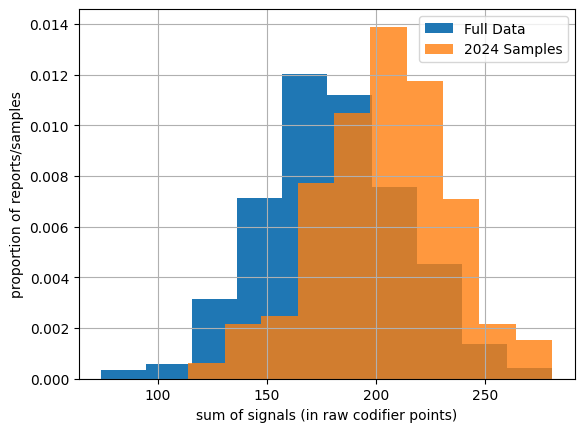

In [10]:
fig, ax = plt.subplots()

all_df['sum'].hist(label='Full Data', density=True)
all_2024['sum'].hist(label='2024 Samples', density=True, alpha=0.8)
ax.legend()
plt.xlabel("sum of signals (in raw codifier points)")
plt.ylabel("proportion of reports/samples");

We can easily see that there tend to be significantly higher sums of signals in the 2024 samples, which means that Vultologists are marking more signals as time goes on, at least for now (perhaps their perceptions are becoming more refined with time)

Let's check that the properties of the distributions are also similar and what the differences are:

In [11]:
dfit = distfit(n_boots=100)
results = dfit.fit_transform(all_2024['sum'])
dfit.summary[['name', 'score', 'bootstrap_score', 'bootstrap_pass']]

[distfit] >INFO> fit
[distfit] >INFO> transform
[distfit] >INFO> [norm      ] [0.12 sec] [RSS: 1.25083e-05] [loc=203.928 scale=29.919]
[distfit] >INFO> [expon     ] [0.12 sec] [RSS: 0.000508257] [loc=114.000 scale=89.928]
[distfit] >INFO> [pareto    ] [0.22 sec] [RSS: 0.000508257] [loc=-8589934478.000 scale=8589934592.000]
[distfit] >INFO> [dweibull  ] [1.11 sec] [RSS: 1.62774e-05] [loc=204.257 scale=25.379]
[distfit] >INFO> [t         ] [8.41 sec] [RSS: 1.2409e-05] [loc=203.995 scale=29.935]
[distfit] >INFO> [genextreme] [12.2 sec] [RSS: 0.000738871] [loc=280.313 scale=3.938]
[distfit] >INFO> [gamma     ] [2.80 sec] [RSS: 1.60373e-05] [loc=-380.119 scale=1.569]
[distfit] >INFO> [lognorm   ] [0.28 sec] [RSS: 1.25095e-05] [loc=-2062765.405 scale=2062969.333]
[distfit] >INFO> [beta      ] [3.34 sec] [RSS: 8.63361e-06] [loc=-370939944.972 scale=370940433.412]
[distfit] >INFO> [uniform   ] [0.11 sec] [RSS: 0.000296405] [loc=114.000 scale=167.000]
[distfit] >INFO> [loggamma  ] [2.28 sec] [R

,name,score,bootstrap_score,bootstrap_pass
0,loggamma,0.000008,0.69,True
1,beta,0.000009,0.69,True
2,dweibull,0.000016,0.58,True
3,norm,0.000013,0.43,True
4,t,0.000012,0.42,True
5,lognorm,0.000013,0.35,True
6,gamma,0.000016,0.13,True
7,genextreme,0.000739,0.03,False
8,uniform,0.000296,0.0,False
9,expon,0.000508,0.0,False


[distfit] >INFO> Ploting Summary.
[distfit] >INFO> Bootstrap results are included..


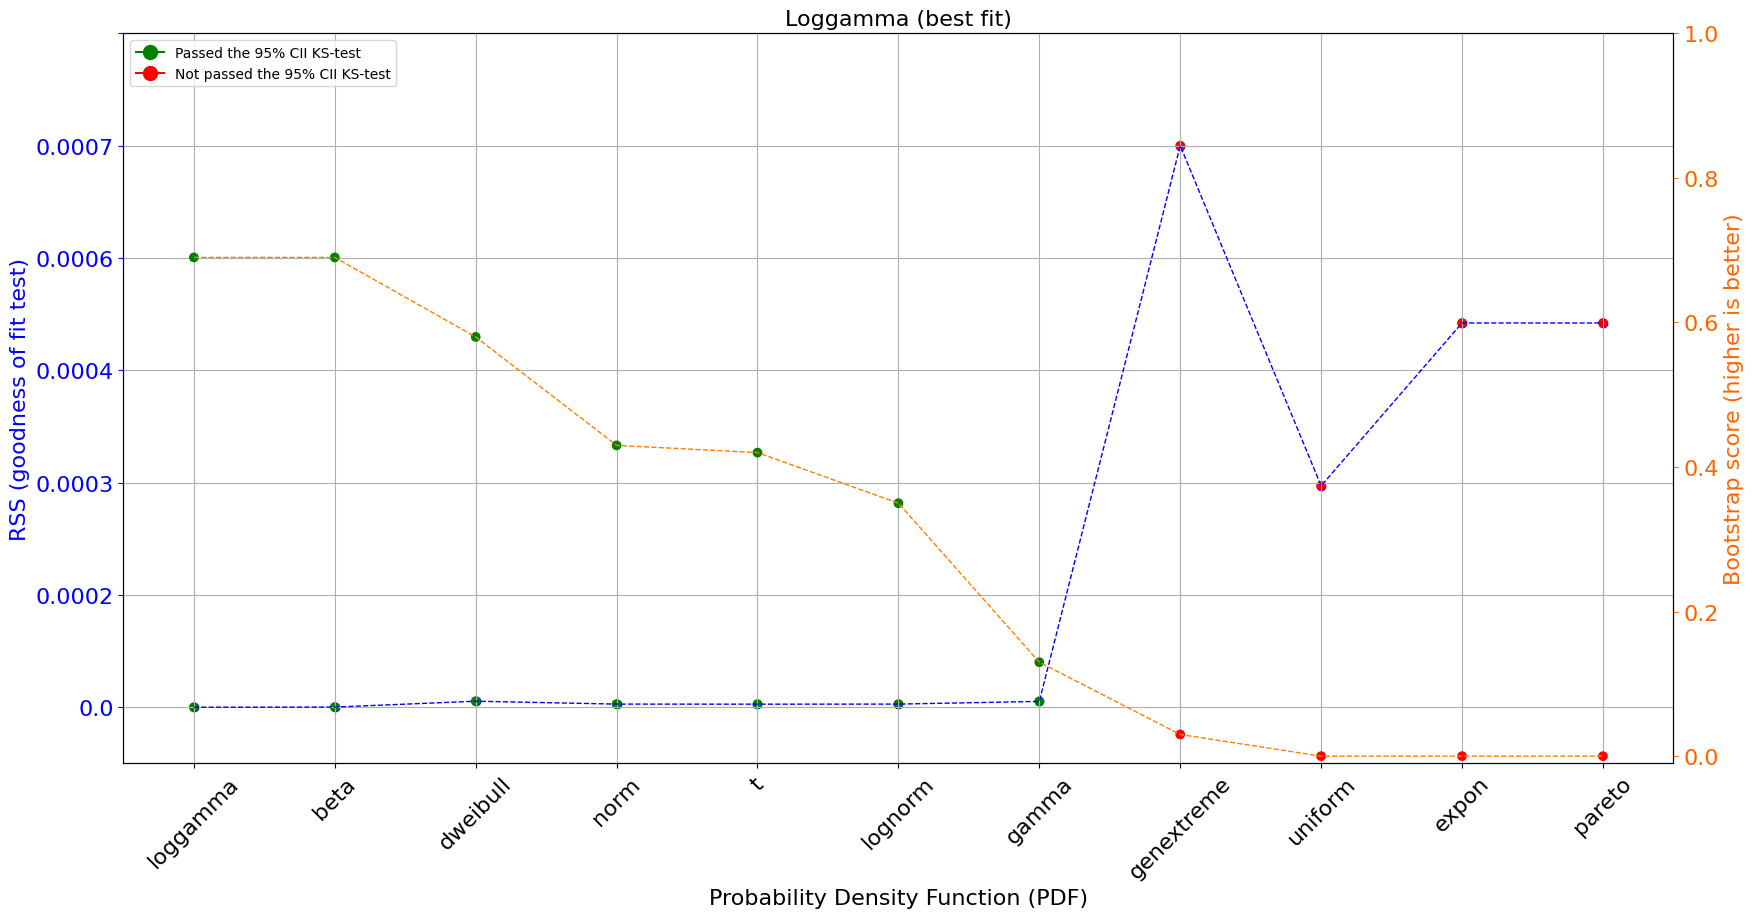

In [12]:
dfit.plot_summary();

It mostly fits the same distributions as with the full data, but it also excludes genextreme which is good because genextreme doesn't seem to make any sense here since it typically deals with extreme values. We're looking for something closer to a normal distribution which works here

In [13]:
all_df['sum'].mean(), all_2024['sum'].mean()

(180.91517857142858, 203.9278350515464)

In [17]:
all_df['sum'].median(), all_2024['sum'].median()

(179.5, 207.0)

So on average we have 23 points higher per report in 2024 compared to the full data, which is as much as about 3 signals marked high, 6 signals marked medium and 12 signals marked low. That is a very large difference. And for median, which is probably a better central tendency to use because of skew, the difference is even more drastic

In [15]:
all_df['sum'].std(), all_2024['sum'].std()

(32.79303670903255, 29.996803775393968)

2024 sample reports also have a lower standard deviation in their sum of signals, which is a sign that reports are being done in an even more balanced way with fewer extreme variations

In [16]:
all_df['sum'].skew(), all_2024['sum'].skew()

(0.03094992034450804, -0.2394343175291393)

There is however a bit more skew in the 2024 signal sums, and the skew changes its direction to the left (so lower reports are a bit more common instead of higher ones). It's still very low skew though so not significant

In [18]:
all_df['sum'].kurtosis(), all_2024['sum'].kurtosis()

(0.11506639126742702, 0.24755238811100577)

These are still pretty low values of kurtosis as well but both distributions are slightly leptokurtic

Overall, the mean and median (central tendencies) of these distributions is the main source of the statistically significant difference in the distributions, and it is VERY noteworthy

### Signal Mixing <a id="MixingFD"></a>

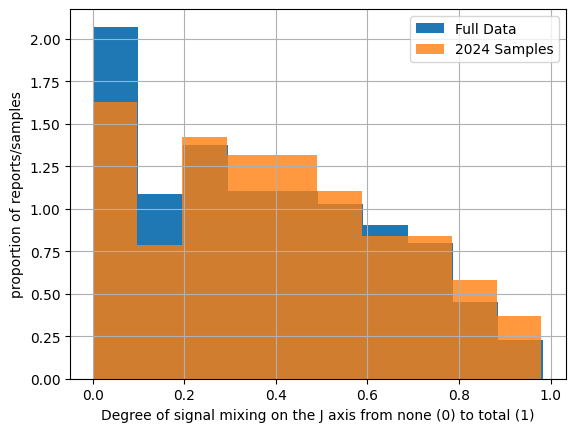

In [19]:
fig, ax = plt.subplots()

all_df['J_Signal_Mixing'].hist(label='Full Data', density=True)
all_2024['J_Signal_Mixing'].hist(label='2024 Samples', density=True, alpha=0.8)
ax.legend()
plt.xlabel("Degree of signal mixing on the J axis from none (0) to total (1)")
plt.ylabel("proportion of reports/samples");

What's noteworthy here is that samples tend to have higher signal mixing in 2024 as well, likely due to greater efforts to pay attention to avoiding the neglect of signal mixing by Vultologists, causing them to mark more signals on both axes (which also partly explains higher sums of signals).

In [20]:
dfit = distfit(n_boots=100)
results = dfit.fit_transform(all_2024['J_Signal_Mixing'])
dfit.summary[['name', 'score', 'bootstrap_score', 'bootstrap_pass']]

[distfit] >INFO> fit
[distfit] >INFO> transform
[distfit] >INFO> [norm      ] [0.13 sec] [RSS: 1.26214] [loc=0.405 scale=0.260]
[distfit] >INFO> [expon     ] [0.12 sec] [RSS: 2.02304] [loc=0.000 scale=0.405]
[distfit] >INFO> [pareto    ] [0.27 sec] [RSS: 7.60762] [loc=-0.000 scale=0.000]
[distfit] >INFO> [dweibull  ] [0.87 sec] [RSS: 1.38951] [loc=0.425 scale=0.242]
[distfit] >INFO> [t         ] [7.46 sec] [RSS: 1.26214] [loc=0.405 scale=0.260]
[distfit] >INFO> [genextreme] [4.74 sec] [RSS: 1.15438] [loc=0.307 scale=0.246]
[distfit] >INFO> [gamma     ] [1.27 sec] [RSS: 1.12421] [loc=-0.363 scale=0.093]
[distfit] >INFO> [lognorm   ] [2.03 sec] [RSS: 10.532] [loc=-0.000 scale=0.000]
[distfit] >INFO> [beta      ] [5.18 sec] [RSS: 1.78469] [loc=-0.000 scale=1.113]
[distfit] >INFO> [uniform   ] [0.11 sec] [RSS: 1.32375] [loc=0.000 scale=0.980]
[distfit] >INFO> [loggamma  ] [3.03 sec] [RSS: 1.25492] [loc=-68.137 scale=9.531]
[distfit] >INFO> [norm      ] [25.2 sec] [RSS: 1.26214] [loc=0.405 

,name,score,bootstrap_score,bootstrap_pass
0,genextreme,1.154379,0.19,True
1,dweibull,1.389506,0.08,True
2,norm,1.262144,0.07,True
3,t,1.262142,0.06,True
4,gamma,1.124206,0.05,False
5,loggamma,1.254919,0.02,False
6,uniform,1.323753,0.0,False
7,beta,1.784693,0.0,False
8,expon,2.023041,0.0,False
9,pareto,7.607615,0.0,False


[distfit] >INFO> Ploting Summary.
[distfit] >INFO> Bootstrap results are included..


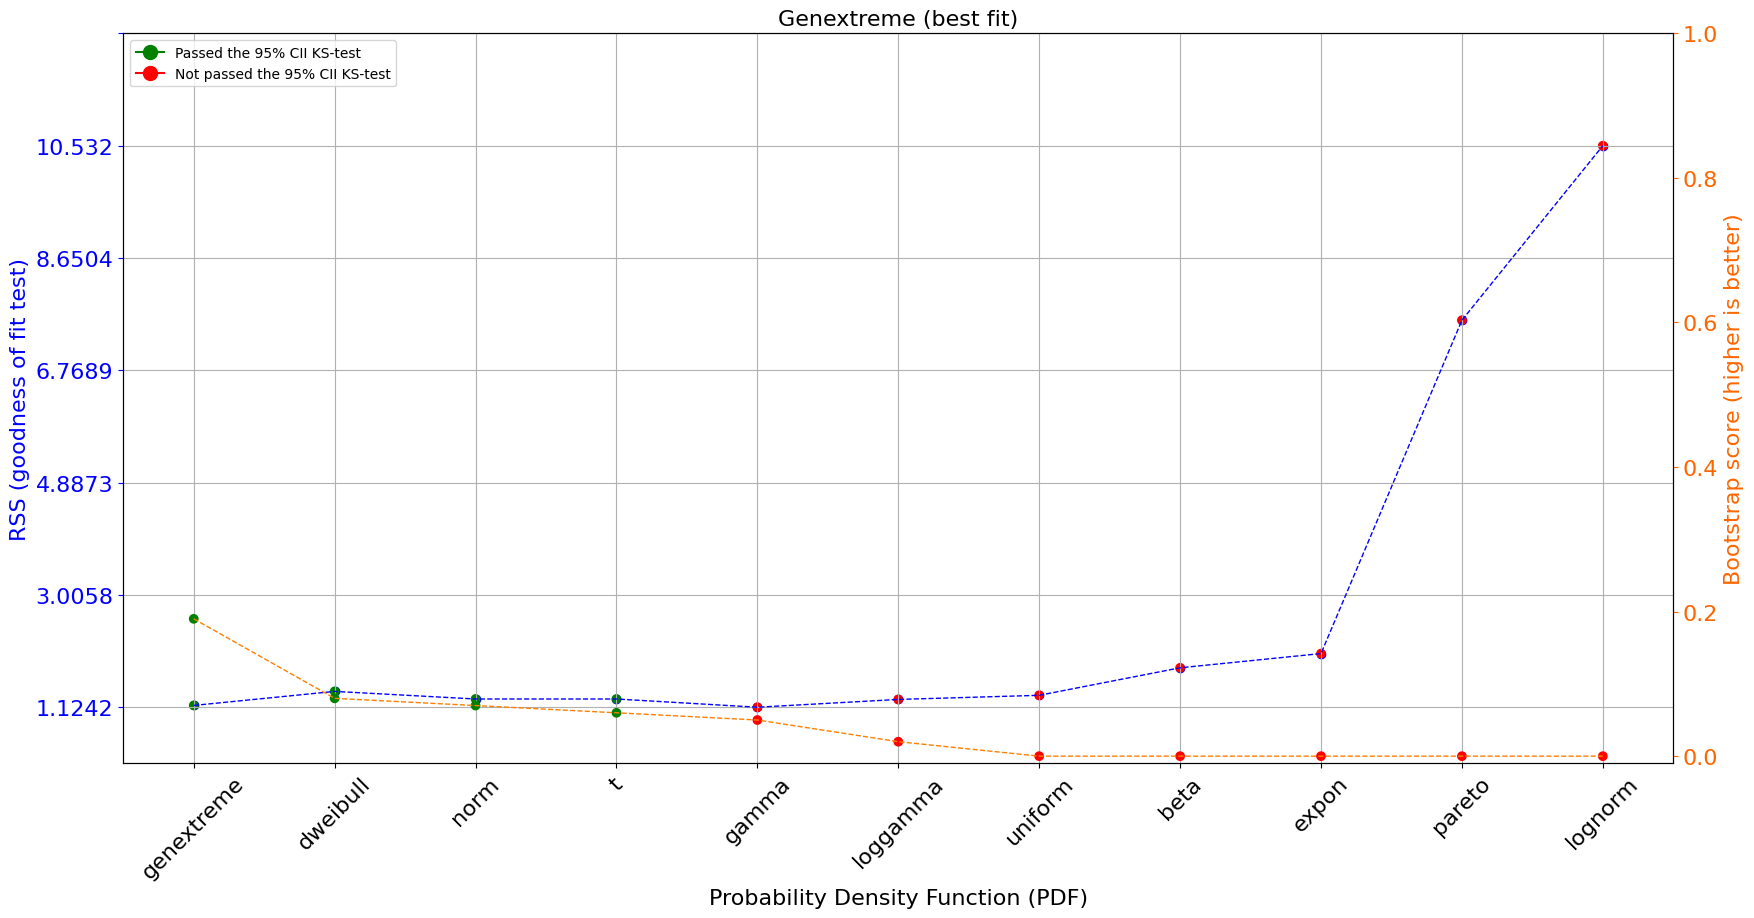

In [21]:
dfit.plot_summary();

This is getting clearer distributions than from before, and it's closest to a genextreme distribution from the popular choices, which could make sense for signal mixing because signal mixing does tend to have more extreme values being what's noteworthy in the measurement

In [47]:
dfit = distfit(n_boots=100, distr='full')
results = dfit.fit_transform(all_2024['J_Signal_Mixing'])
dfit.summary[['name', 'score', 'bootstrap_score', 'bootstrap_pass']]

[distfit] >INFO> fit
[distfit] >INFO> transform
[distfit] >INFO> [alpha          ] [3.59 sec] [RSS: 1.18104] [loc=-3.496 scale=58.668]
[distfit] >INFO> [anglit         ] [0.41 sec] [RSS: 1.03092] [loc=0.432 scale=0.732]
[distfit] >INFO> [arcsine        ] [1.99 sec] [RSS: 2.56712] [loc=-0.000 scale=0.982]
[distfit] >INFO> [beta           ] [5.12 sec] [RSS: 1.78469] [loc=-0.000 scale=1.113]
[distfit] >INFO> [betaprime      ] [5.37 sec] [RSS: 1.09933] [loc=-0.206 scale=76751696795.528]
[distfit] >INFO> [bradford       ] [2.26 sec] [RSS: 0.754064] [loc=-0.000 scale=0.980]
[distfit] >INFO> [burr           ] [10.8 sec] [RSS: 1.74706] [loc=-0.000 scale=0.650]
[distfit] >INFO> [cauchy         ] [0.37 sec] [RSS: 2.14742] [loc=0.379 scale=0.176]
[distfit] >INFO> [chi            ] [3.90 sec] [RSS: 2.29134] [loc=-0.000 scale=0.516]
[distfit] >INFO> [chi2           ] [4.02 sec] [RSS: 3.50375] [loc=-0.000 scale=0.334]
[distfit] >INFO> [cosine         ] [0.57 sec] [RSS: 1.11658] [loc=0.416 scale=0.21

,name,score,bootstrap_score,bootstrap_pass
0,gennorm,1.323753,1.0,True
1,truncnorm,0.601279,0.53,True
2,bradford,0.754064,0.34,True
3,gompertz,0.624954,0.27,True
4,weibull_max,1.154371,0.23,True
...,...,...,...,...
75,nakagami,3.68443,0.0,False
76,pareto,7.607615,0.0,False
77,powerlaw,9.367351,0.0,False
78,lognorm,10.531985,0,None


In [48]:
dfit.summary[['name', 'score', 'bootstrap_score', 'bootstrap_pass']].head(35)

,name,score,bootstrap_score,bootstrap_pass
0,gennorm,1.323753,1.0,True
1,truncnorm,0.601279,0.53,True
2,bradford,0.754064,0.34,True
3,gompertz,0.624954,0.27,True
4,weibull_max,1.154371,0.23,True
5,cosine,1.116578,0.22,True
6,invgamma,1.171671,0.19,True
7,halfgennorm,0.494888,0.18,True
8,genextreme,1.154379,0.18,True
9,reciprocal,6.068186,0.17,True


[distfit] >INFO> Ploting Summary.
[distfit] >INFO> Bootstrap results are included..


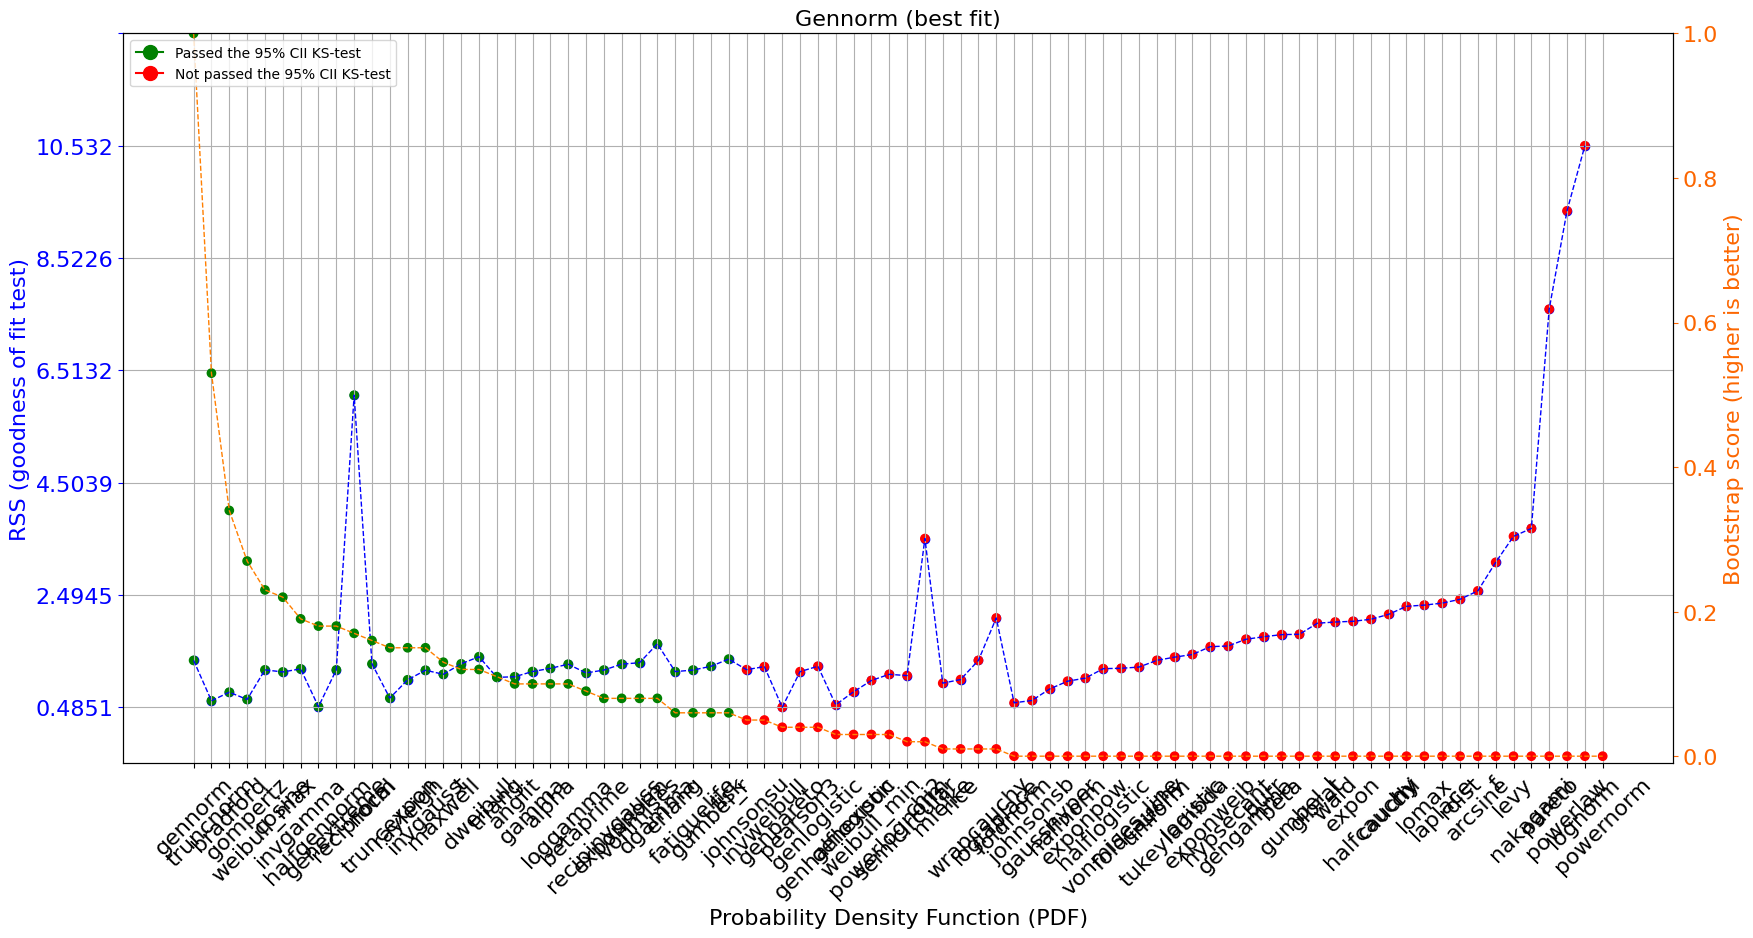

In [49]:
dfit.plot_summary();

[distfit] >INFO> Create PDF plot for the parametric method.
[distfit] >INFO> Estimated distribution: Gennorm(loc:0.489796, scale:0.489797)
[distfit] >INFO> Create CDF plot for the parametric method.
[distfit] >INFO> Ploting CDF


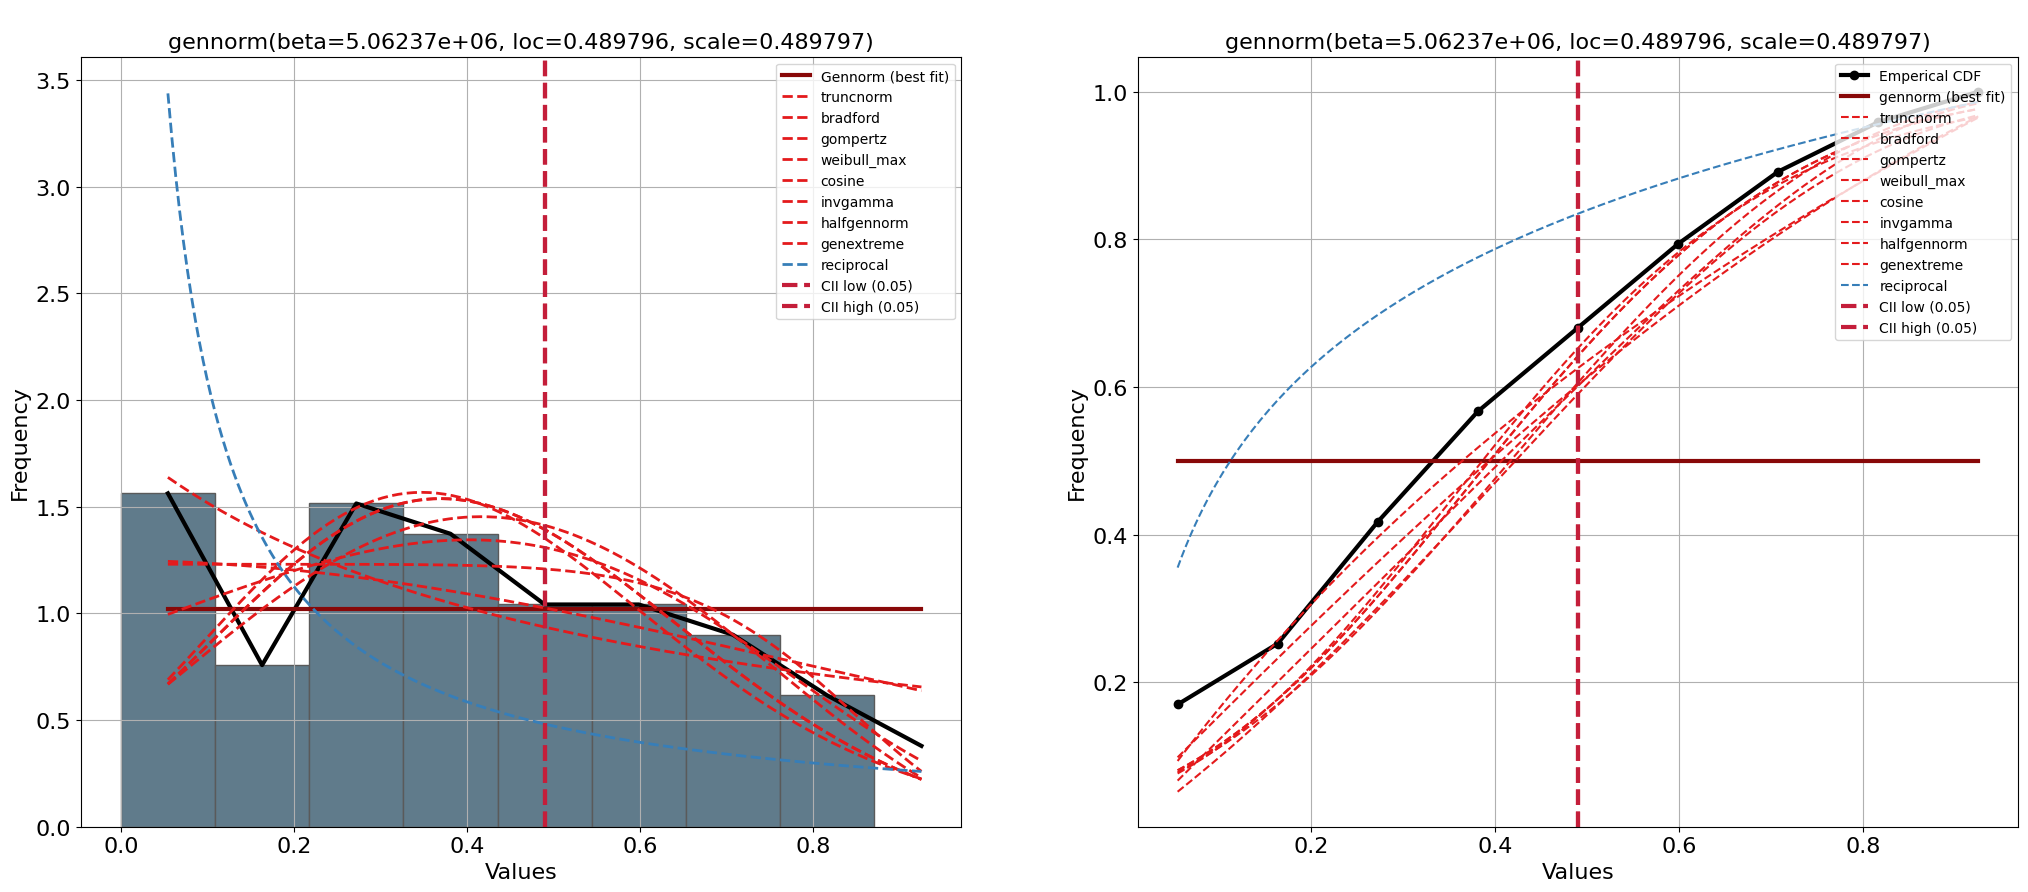

In [50]:
fig, ax = plt.subplots(1,2, figsize=(25, 10))
# Plot PDF with histogram
dfit.plot(chart='PDF', n_top=9, ax=ax[0])
# Plot the CDF
dfit.plot(chart='CDF', n_top=9, ax=ax[1]);

The best performing distributions in this case seem to be parts of normal distributions (like truncnorm, halfgennorm), which seems fitting, but ultimately none of these seem to fit very well in terms of capturig the peaks of the distro. Gennorm, which did the best on the bootstrap test, looks not even slightly fitting.

In [27]:
all_df['J_Signal_Mixing'].mean(), all_2024['J_Signal_Mixing'].mean()

(0.36894129416977967, 0.4051279174500675)

In [28]:
all_df['J_Signal_Mixing'].median(), all_2024['J_Signal_Mixing'].median()

(0.34534161490683224, 0.3874296435272045)

So there is on average more J signal mixing but the amount more doesn't seem especially drastic, it might be increasing because there are just fewer with very low signal mixing

In [29]:
all_df['J_Signal_Mixing'].var(), all_2024['J_Signal_Mixing'].var()

(0.06975580649379065, 0.0679572205972343)

Nearly identical variance

In [30]:
all_df['J_Signal_Mixing'].skew(), all_2024['J_Signal_Mixing'].skew()

(0.2754383580838698, 0.21139701654371684)

A bit right skewed but not by a lot

In [31]:
all_df['J_Signal_Mixing'].kurtosis(), all_2024['J_Signal_Mixing'].kurtosis()

(-0.9704253213724985, -0.8809119267857004)

So the main difference does seem to be the mean/median on average being higher without the other distribution properties changing much, so the overall shape is still similar. J Signal Mixing was less statistically significant than sum and P Signal Mixing however, so that might explain why we aren't seeing as drastic of differences in this case

Let's look at P Signal Mixing

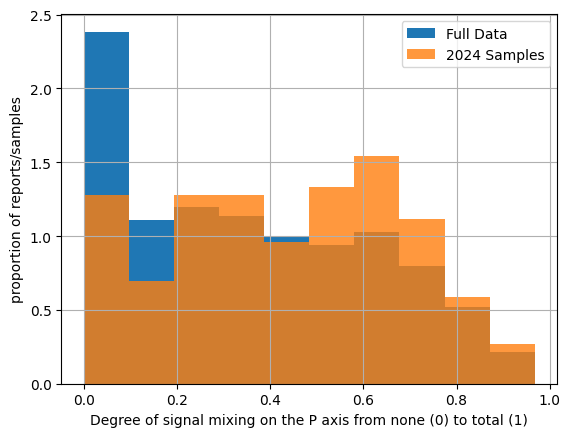

In [32]:
fig, ax = plt.subplots()

all_df['P_Signal_Mixing'].hist(label='Full Data', density=True)
all_2024['P_Signal_Mixing'].hist(label='2024 Samples', density=True, alpha=0.8)
ax.legend()
plt.xlabel("Degree of signal mixing on the P axis from none (0) to total (1)")
plt.ylabel("proportion of reports/samples");

It's a very similar difference as recorded in the J Signal Mixing graph, but the difference here is more drastic, both on lower (under 0.2) and higher (0.5 and greater) ends of the x-axis, there is a notably higher proportion of samples with middling signal mixing values such as ~0.6

In [33]:
dfit = distfit(n_boots=100)
results = dfit.fit_transform(all_2024['P_Signal_Mixing'])
dfit.summary[['name', 'score', 'bootstrap_score', 'bootstrap_pass']]

[distfit] >INFO> fit
[distfit] >INFO> transform
[distfit] >INFO> [norm      ] [0.17 sec] [RSS: 1.34154] [loc=0.437 scale=0.250]
[distfit] >INFO> [expon     ] [0.12 sec] [RSS: 3.24229] [loc=0.000 scale=0.437]
[distfit] >INFO> [pareto    ] [0.29 sec] [RSS: 8.54852] [loc=-0.000 scale=0.000]
[distfit] >INFO> [dweibull  ] [0.92 sec] [RSS: 0.649333] [loc=0.433 scale=0.240]
[distfit] >INFO> [t         ] [7.28 sec] [RSS: 1.34154] [loc=0.437 scale=0.250]
[distfit] >INFO> [genextreme] [8.17 sec] [RSS: 3.8765] [loc=0.148 scale=0.836]
[distfit] >INFO> [gamma     ] [2.98 sec] [RSS: 1.3608] [loc=-5.986 scale=0.010]
[distfit] >INFO> [lognorm   ] [3.73 sec] [RSS: 10.8897] [loc=-0.000 scale=0.000]
[distfit] >INFO> [beta      ] [5.08 sec] [RSS: 1.74117] [loc=-0.000 scale=0.968]
[distfit] >INFO> [uniform   ] [0.11 sec] [RSS: 1.4345] [loc=0.000 scale=0.968]
[distfit] >INFO> [loggamma  ] [2.15 sec] [RSS: 1.31027] [loc=-3.388 scale=1.212]
[distfit] >INFO> [norm      ] [31.0 sec] [RSS: 1.34154] [loc=0.437 sc

,name,score,bootstrap_score,bootstrap_pass
0,dweibull,0.649333,0.43,True
1,loggamma,1.310269,0.02,False
2,norm,1.341543,0.02,False
3,t,1.34154,0.01,False
4,uniform,1.434504,0.01,False
5,gamma,1.360799,0.0,False
6,beta,1.741167,0.0,False
7,expon,3.242288,0.0,False
8,genextreme,3.876496,0.0,False
9,pareto,8.548516,0.0,False


[distfit] >INFO> Ploting Summary.
[distfit] >INFO> Bootstrap results are included..


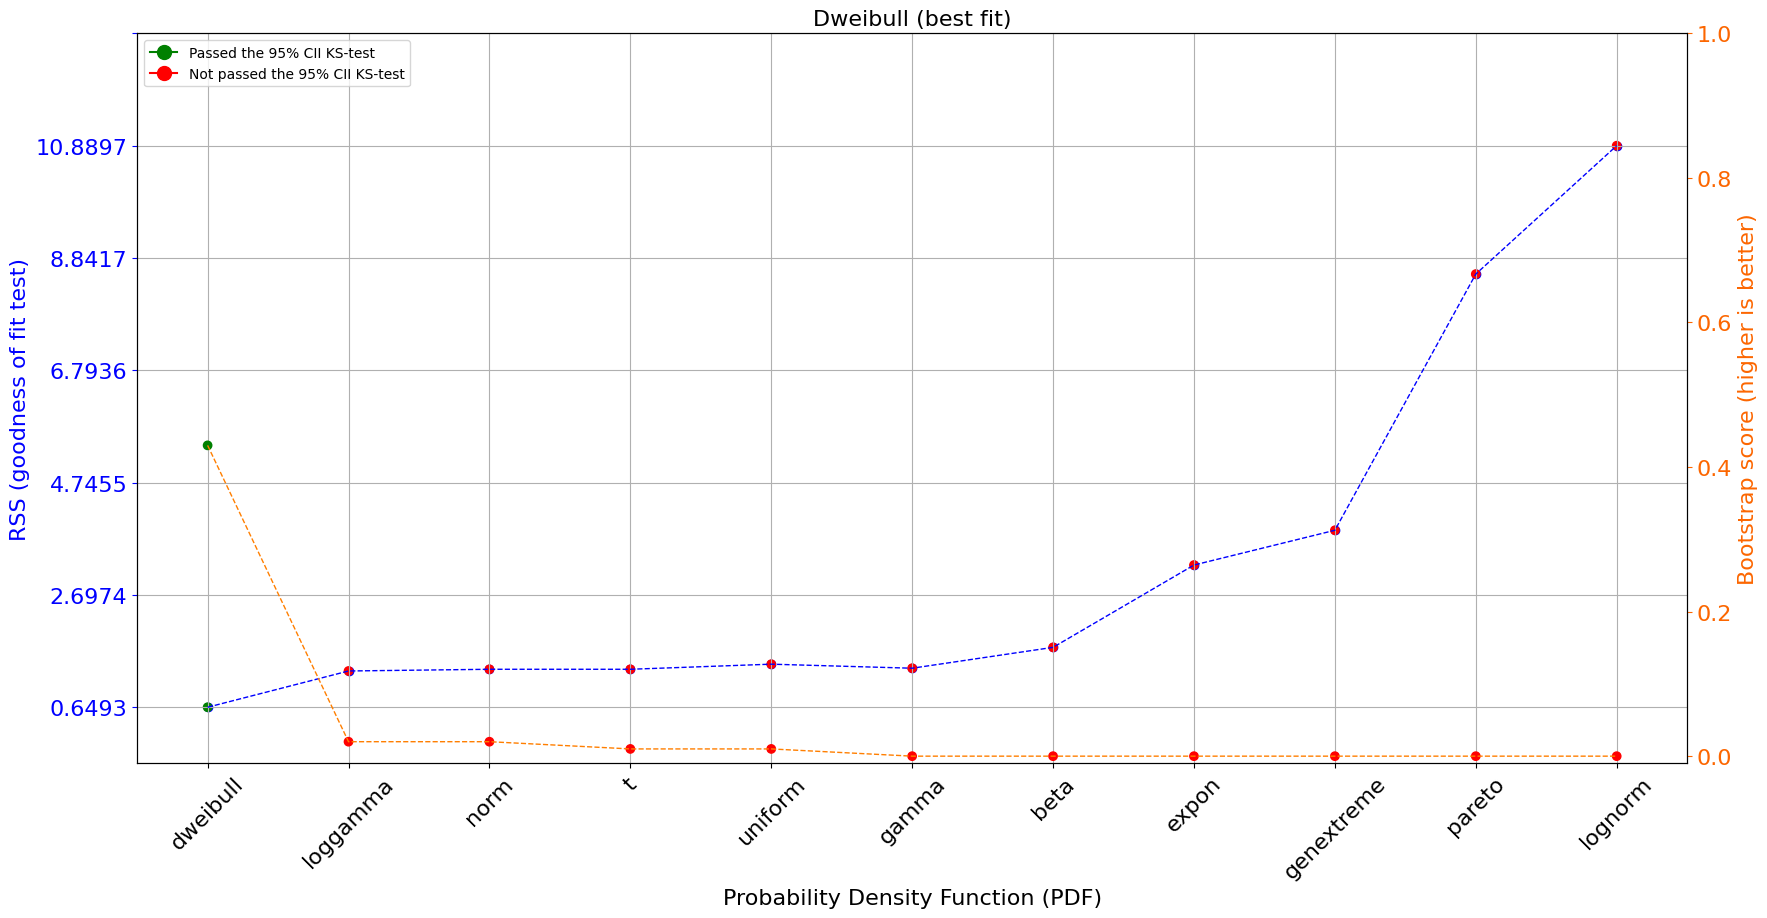

In [34]:
dfit.plot_summary();

What's working best by far is the two peaked dweibull distribution, which is not what we were getting before

In [35]:
dfit = distfit(n_boots=100, distr='full')
results = dfit.fit_transform(all_2024['P_Signal_Mixing'])
dfit.summary[['name', 'score', 'bootstrap_score', 'bootstrap_pass']]

[distfit] >INFO> fit
[distfit] >INFO> transform
[distfit] >INFO> [alpha          ] [3.89 sec] [RSS: 1.41465] [loc=-5.463 scale=137.975]
[distfit] >INFO> [anglit         ] [0.41 sec] [RSS: 0.849288] [loc=0.441 scale=0.705]
[distfit] >INFO> [arcsine        ] [1.93 sec] [RSS: 3.43399] [loc=-0.000 scale=0.970]
[distfit] >INFO> [beta           ] [5.13 sec] [RSS: 1.74117] [loc=-0.000 scale=0.968]
[distfit] >INFO> [betaprime      ] [5.19 sec] [RSS: 1.34134] [loc=-57.513 scale=22.559]
[distfit] >INFO> [bradford       ] [2.16 sec] [RSS: 1.31944] [loc=-0.000 scale=0.968]
[distfit] >INFO> [burr           ] [10.8 sec] [RSS: 2.29269] [loc=-0.000 scale=0.786]
[distfit] >INFO> [cauchy         ] [0.35 sec] [RSS: 2.68672] [loc=0.462 scale=0.178]
[distfit] >INFO> [chi            ] [1.38 sec] [RSS: 1.31878] [loc=-0.168 scale=0.383]
[distfit] >INFO> [chi2           ] [3.70 sec] [RSS: 1.37579] [loc=-1.693 scale=0.015]
[distfit] >INFO> [cosine         ] [0.52 sec] [RSS: 1.06408] [loc=0.435 scale=0.210]
[dis

,name,score,bootstrap_score,bootstrap_pass
0,dgamma,0.882316,0.6,True
1,truncnorm,1.073691,0.56,True
2,chi2,1.375792,0.44,True
3,gennorm,0.628962,0.4,True
4,dweibull,0.649333,0.37,True
...,...,...,...,...
75,lomax,4.833151,0.0,False
76,reciprocal,8.066956,0.0,False
77,pareto,8.548516,0.0,False
78,powerlaw,9.812987,0.0,False


In [37]:
dfit.summary[['name', 'score', 'bootstrap_score', 'bootstrap_pass']].head(20)

,name,score,bootstrap_score,bootstrap_pass
0,dgamma,0.882316,0.6,True
1,truncnorm,1.073691,0.56,True
2,chi2,1.375792,0.44,True
3,gennorm,0.628962,0.4,True
4,dweibull,0.649333,0.37,True
5,anglit,0.849288,0.32,True
6,halfgennorm,0.565404,0.3,True
7,semicircular,0.814884,0.29,True
8,cosine,1.06408,0.16,True
9,gompertz,0.748375,0.11,True


[distfit] >INFO> Ploting Summary.
[distfit] >INFO> Bootstrap results are included..


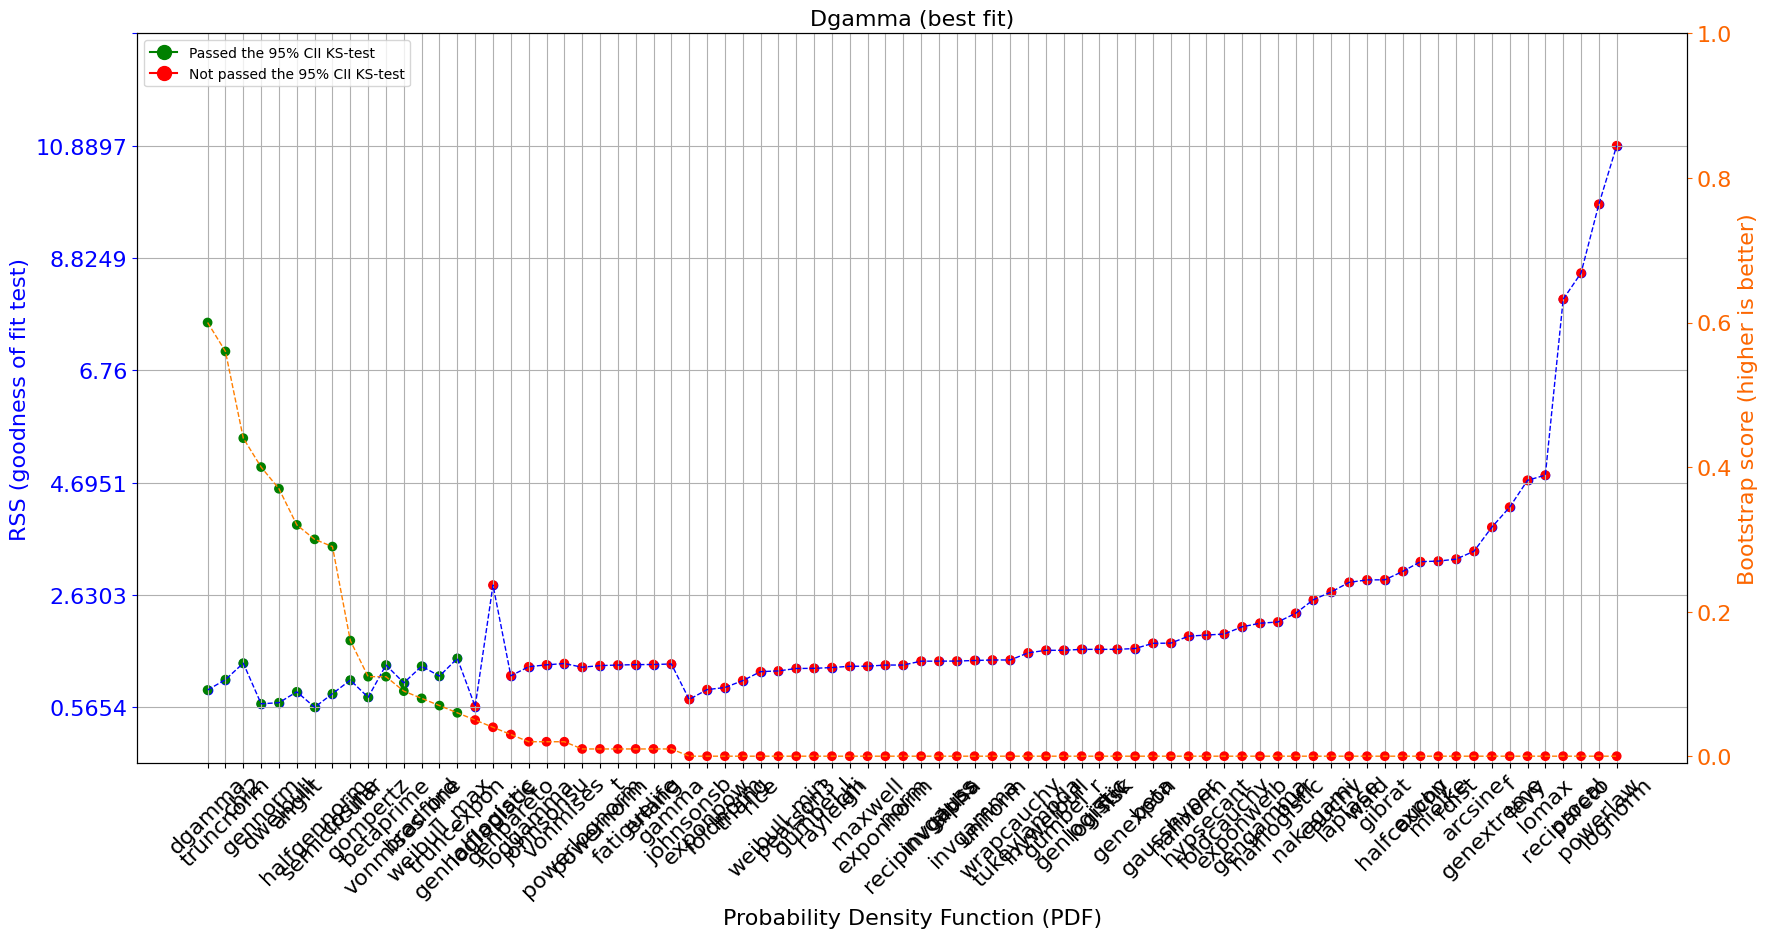

In [38]:
dfit.plot_summary();

[distfit] >INFO> Create PDF plot for the parametric method.
[distfit] >INFO> Estimated distribution: Dgamma(loc:0.433166, scale:0.099444)
[distfit] >INFO> Create CDF plot for the parametric method.
[distfit] >INFO> Ploting CDF


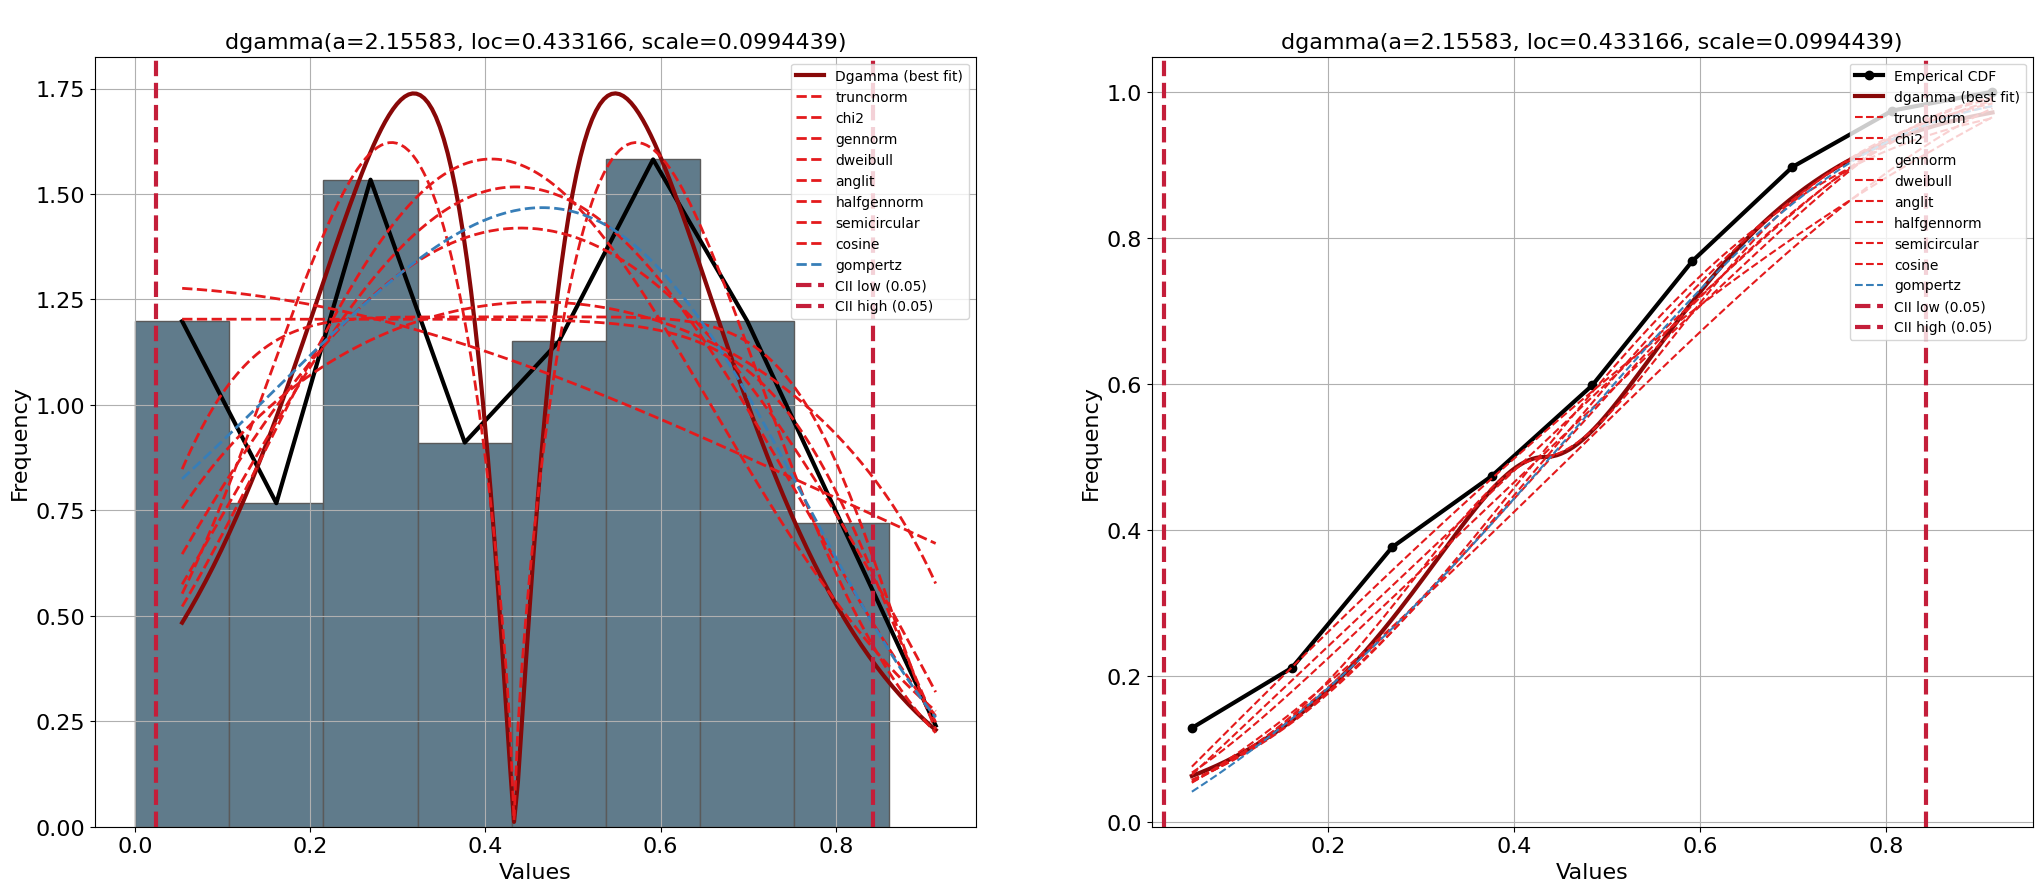

In [39]:
fig, ax = plt.subplots(1,2, figsize=(25, 10))
# Plot PDF with histogram
dfit.plot(chart='PDF', n_top=9, ax=ax[0])
# Plot the CDF
dfit.plot(chart='CDF', n_top=9, ax=ax[1]);

There are roughly 3 different sorts of distros here:
- one's like dgamma and dweibull with two peaks
- one's vaguely similar to a normal distribution
- funky one's like the gennorm with a flat top and truncnorm that's not much different from a straightline

The only thing that seems clear to me is that none fit very well here, so it's just a pretty nonstandard distribution

In [51]:
all_df['P_Signal_Mixing'].mean(), all_2024['P_Signal_Mixing'].mean()

(0.3507834467044167, 0.4372148276655788)

In [52]:
all_df['P_Signal_Mixing'].median(), all_2024['P_Signal_Mixing'].median()

(0.3157894736842105, 0.46606334841628955)

In this case we have a significantly larger increase in central tendency which is undoubtedly why P Signal Mixing was found to be more statistically significant than J Signal Mixing

In [53]:
all_df['P_Signal_Mixing'].var(), all_2024['P_Signal_Mixing'].var()

(0.07379540367604927, 0.06271625913932326)

Variance is less similar in the case of P Signal Mixing as well which is another contributor to statistical significance

In [54]:
all_df['P_Signal_Mixing'].skew(), all_2024['P_Signal_Mixing'].skew()

(0.2624319311943711, -0.10825382840818142)

Skew has a surprisingly significant difference, not even because the magnitude is large, but because it changes direction. It's not very skewed though so I'd say it doesn't matter much

In [55]:
all_df['P_Signal_Mixing'].kurtosis(), all_2024['P_Signal_Mixing'].kurtosis()

(-1.0749139916874537, -0.9380431085766046)

So the consistent theme is for the central tendency of the data to increase significantly in 2024 samples, due to more signals being marked for various reasons and leading to more signal mixing. The rest mostly doesn't seem especially noteworthy, except perhaps that no standard distributions fits the Signal Mixing distribution very well

## Mann-Whitney Tests <a id="MWFD"></a>

In this case we are going to look at nearly every other column, since they are all either categorical in nature or consist of signals with mainly discrete values and thus a lot of ties that make the KS test ineffective

In [56]:
MW_cols = [col for col in list(all_2024.columns) if (col not in KS_cols) and (col not in ['Sample Name', 'Vultologist'])]

MW_results = {}

for col in MW_cols:
    if all_df[col].dtype == 'O':
        stat, p_value = mannwhitneyu(all_df[col].value_counts(), all_2024[col].value_counts())
    else:
        stat, p_value = mannwhitneyu(all_df[col], all_2024[col])
    MW_results[col] = {'statistic': stat, 'p_value': p_value.round(3)}

MW_df = pd.DataFrame.from_dict(MW_results)
with pd.option_context("display.max_rows", 1000):
    print(MW_df.transpose().sort_values('p_value'))

                               statistic  p_value
Type                               252.5    0.000
PF4 Casual Hands                 49881.5    0.000
MS9 Puppeteer Hands              52973.0    0.000
GR5 Pointed Eye Toggles          53844.5    0.000
GR7 Grounding Effect             54285.5    0.000
GR8 Bodily Awareness             51171.0    0.000
F4 Horizontal Movements          50999.0    0.000
RR1 Poised Receding              54791.5    0.000
EU1 Responsive Nodding           54678.0    0.000
PR3 Shoulder Shrugs              55483.5    0.001
RR3 Exerted Pushes               56025.0    0.001
Development                         63.5    0.001
PF3 Body Swaying                 55280.5    0.001
F3 Gliding Motions               55761.5    0.001
PF2 Toggling Eyes                55271.5    0.001
PR4 Fluent Articulation          56028.0    0.002
EU2 Polite Smiling               56426.0    0.003
GR6 Eye Head Parallel Motion     56415.0    0.003
MS2 Horizontal Curtain Smiles    56546.0    0.003


Seemingly half of these distributions have statistically significant differences, so we'll have to look at just about everything. We can exclude things like Fallen Affect, Sex, Geography, and Ethnicity since they don't have statistically significant changes

For most of these columns, in particular the vultology signals, I think it will just mirror the increasing sum and we'll see a shift to greater values of most of the signals

### Type Distribution <a id="TypeFD"></a>

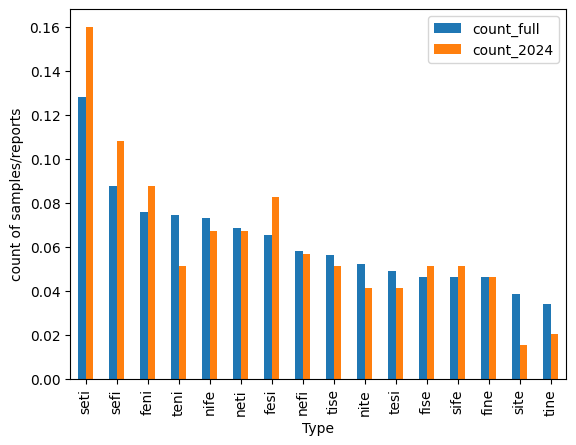

In [57]:
type_join = (all_df['Type'].value_counts()/len(all_df)).to_frame().join((all_2024['Type'].value_counts()/len(all_2024)).to_frame(), lsuffix='_full', rsuffix='_2024')
type_join.plot(use_index=True, y=['count_full', 'count_2024'], kind='bar')
plt.ylabel("count of samples/reports");

In [58]:
Type_counts = all_2024['Type'].value_counts().to_frame()
Type_counts['percent'] = (100 * Type_counts['count'] / len(all_2024['Type'])).round(2)
Type_counts

,count,percent
Type,,
seti,31,15.98
sefi,21,10.82
feni,17,8.76
fesi,16,8.25
neti,13,6.70
nife,13,6.70
nefi,11,5.67
fise,10,5.15
teni,10,5.15


Proportionally we're seeing a large uptick of Se leads (especially) and Fe leads and a downtick in Te Conductors (especially SiTe which has almost none). Not sure anything can be made of that, it's just what was typed due to what the interests were in typing celebs this year, this isn't a random sample

Also nearly none of these have the 30 samples that would be necessary for some statistical tests

### Development <a id="DevelopmentFD"></a>

In [59]:
Dev_counts = all_2024['Development'].value_counts().to_frame()
Dev_counts['percent'] = (100 * Dev_counts['count'] / len(all_2024['Development'])).round(2)
Dev_counts

,count,percent
Development,,
i-i-,33,17.01
ii--,32,16.49
i---,31,15.98
i-ii,29,14.95
iii-,22,11.34
iiii,16,8.25
ii-i,16,8.25
i--i,15,7.73


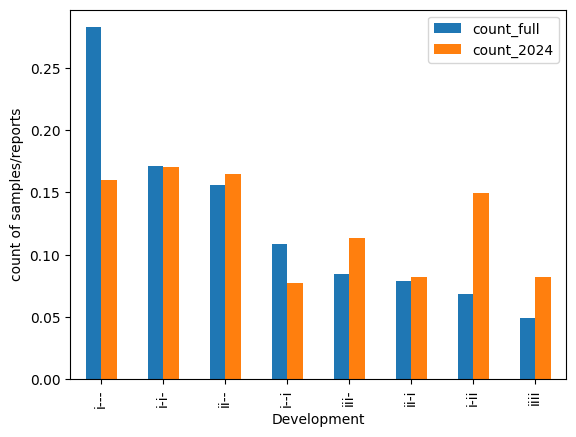

In [60]:
dev_join = (all_df['Development'].value_counts()/len(all_df)).to_frame().join((all_2024['Development'].value_counts()/len(all_2024)).to_frame(), lsuffix='_full', rsuffix='_2024')
dev_join.plot(use_index=True, y=['count_full', 'count_2024'], kind='bar')
plt.ylabel("count of samples/reports");

Proportionally we are saying far fewer i--- devs in 2024 (these used to be the most common but they are only in 3rd place in this year long window of data), we're also seeing more samples with complex developments

This is all explainable by the increasing sums of signals in reports, because with more signals marked, more complex developmenets will occur, thus the grant stack assumptions that originally looked to be supported by Vultology might legitimately no longer hold

### Lead Energetic <a id="LeadFD"></a>

In [61]:
LE_counts = all_2024['Lead Energetic'].value_counts().to_frame()
LE_counts['percent'] = (100 * LE_counts['count'] / len(all_2024)).round(2)
LE_counts

,count,percent
Lead Energetic,,
Pe,76,39.18
Je,51,26.29
Pi,34,17.53
Ji,33,17.01


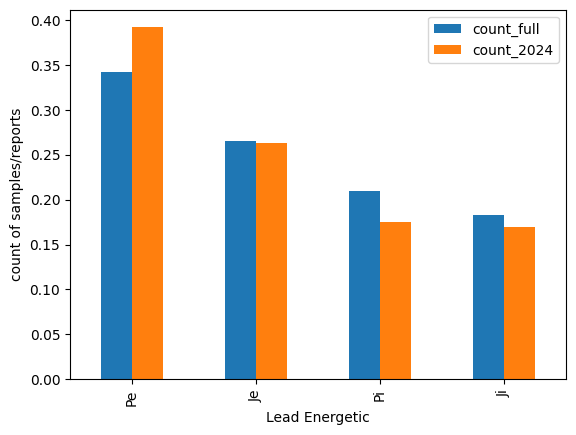

In [62]:
le_join = (all_df['Lead Energetic'].value_counts()/len(all_df)).to_frame().join((all_2024['Lead Energetic'].value_counts()/len(all_2024)).to_frame(), lsuffix='_full', rsuffix='_2024')
le_join.plot(use_index=True, y=['count_full', 'count_2024'], kind='bar')
plt.ylabel("count of samples/reports");

This is not very different from before, it only slightly exacerbates the previous trend of Pe leads being the most and introverts being less common (again the context of mostly celebrity samples)

### Quadra <a id="QuadraFD"></a>

In [63]:
Quadra_counts = all_2024['Quadra'].value_counts().to_frame()
Quadra_counts['percent'] = (100 * Quadra_counts['count'] / len(all_2024)).round(2)
Quadra_counts

,count,percent
Quadra,,
Beta,71,36.60
Gamma,49,25.26
Alpha,43,22.16
Delta,31,15.98


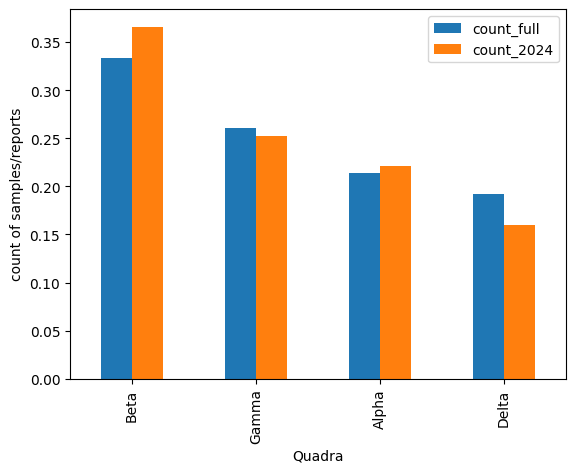

In [64]:
quadra_join = (all_df['Quadra'].value_counts()/len(all_df)).to_frame().join((all_2024['Quadra'].value_counts()/len(all_2024)).to_frame(), lsuffix='_full', rsuffix='_2024')
quadra_join.plot(use_index=True, y=['count_full', 'count_2024'], kind='bar')
plt.ylabel("count of samples/reports");

Again, mostly similar, but we see in uptick in Measured quadras, and the corresponding downtick in Candid quadras, but the effect is pretty small

### Age Range <a id="AgeFD"></a>

In [65]:
Age_counts = all_2024['Age Range'].value_counts().to_frame()
Age_counts['percent'] = (100 * Age_counts['count'] / len(all_2024)).round(2)
Age_counts

,count,percent
Age Range,,
1980s,52,26.80
1990s,40,20.62
1970s,29,14.95
-1,22,11.34
1960s,17,8.76
1940s,12,6.19
1950s,10,5.15
1930s,4,2.06
1900s,3,1.55


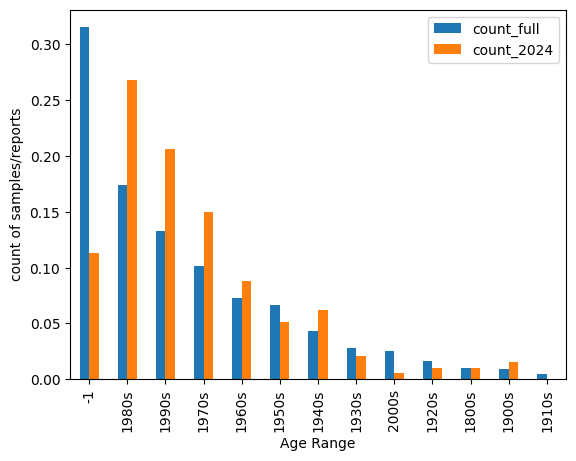

In [66]:
age_join = (all_df['Age Range'].value_counts()/len(all_df)).to_frame().join((all_2024['Age Range'].value_counts()/len(all_2024)).to_frame(), lsuffix='_full', rsuffix='_2024')
age_join.plot(use_index=True, y=['count_full', 'count_2024'], kind='bar')
plt.ylabel("count of samples/reports");

The main difference here just seems to be that there are proportionally much fewer null values, and Vultologists are marking this one on reports much more, which is good. But the distribution itself doesn't seem very different so there isn't anything to conclude

### Emotions <a id="EmotionsFD"></a>

In [67]:
Emotion_counts = all_2024['Emotions'].value_counts().to_frame()
Emotion_counts['percent'] = (100 * Emotion_counts['count'] / len(all_2024)).round(2)
Emotion_counts

,count,percent
Emotions,,
neutral,76,39.18
unguarded,75,38.66
guarded,43,22.16


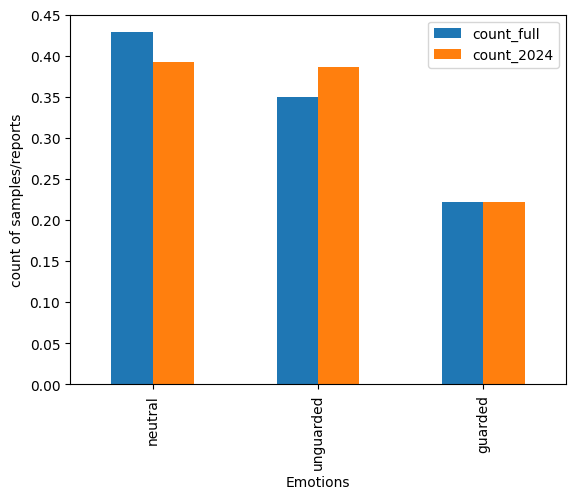

In [68]:
emotion_join = (all_df['Emotions'].value_counts()/len(all_df)).to_frame().join((all_2024['Emotions'].value_counts()/len(all_2024)).to_frame(), lsuffix='_full', rsuffix='_2024')
emotion_join.plot(use_index=True, y=['count_full', 'count_2024'], kind='bar')
plt.ylabel("count of samples/reports");

There are proportionally fewer neutral samples and more unguarded samples in 2024, but it's not by a huge amount so I'm not ready to conclude anything significant from that

Those are all of the categorical variables that we want to explore which had a chance of statistically significant effects, and now we will look at each of the groups of signals and see if they have any changes (the only major change that I expect is on average greater sums and central tendencies for all of them)

### Rigid Signals <a id="RigidFD"></a>

In [69]:
all_2024.loc[:,'R1 Rigid Posture':'R5 Subordinate Fluidity'].describe()

,R1 Rigid Posture,R2 Face Centric,R3 Punctuated Motions,R4 Vertical Movements,R5 Subordinate Fluidity
count,194.000000,194.000000,194.000000,194.000000,194.000000
mean,3.324742,3.355670,3.381443,3.458763,1.922680
std,2.502373,2.454201,2.120433,1.955688,2.363189
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000,2.000000,0.000000
50%,4.000000,3.000000,4.000000,4.000000,0.000000
75%,4.000000,4.000000,4.000000,4.000000,4.000000
max,7.000000,7.000000,7.000000,7.000000,7.000000


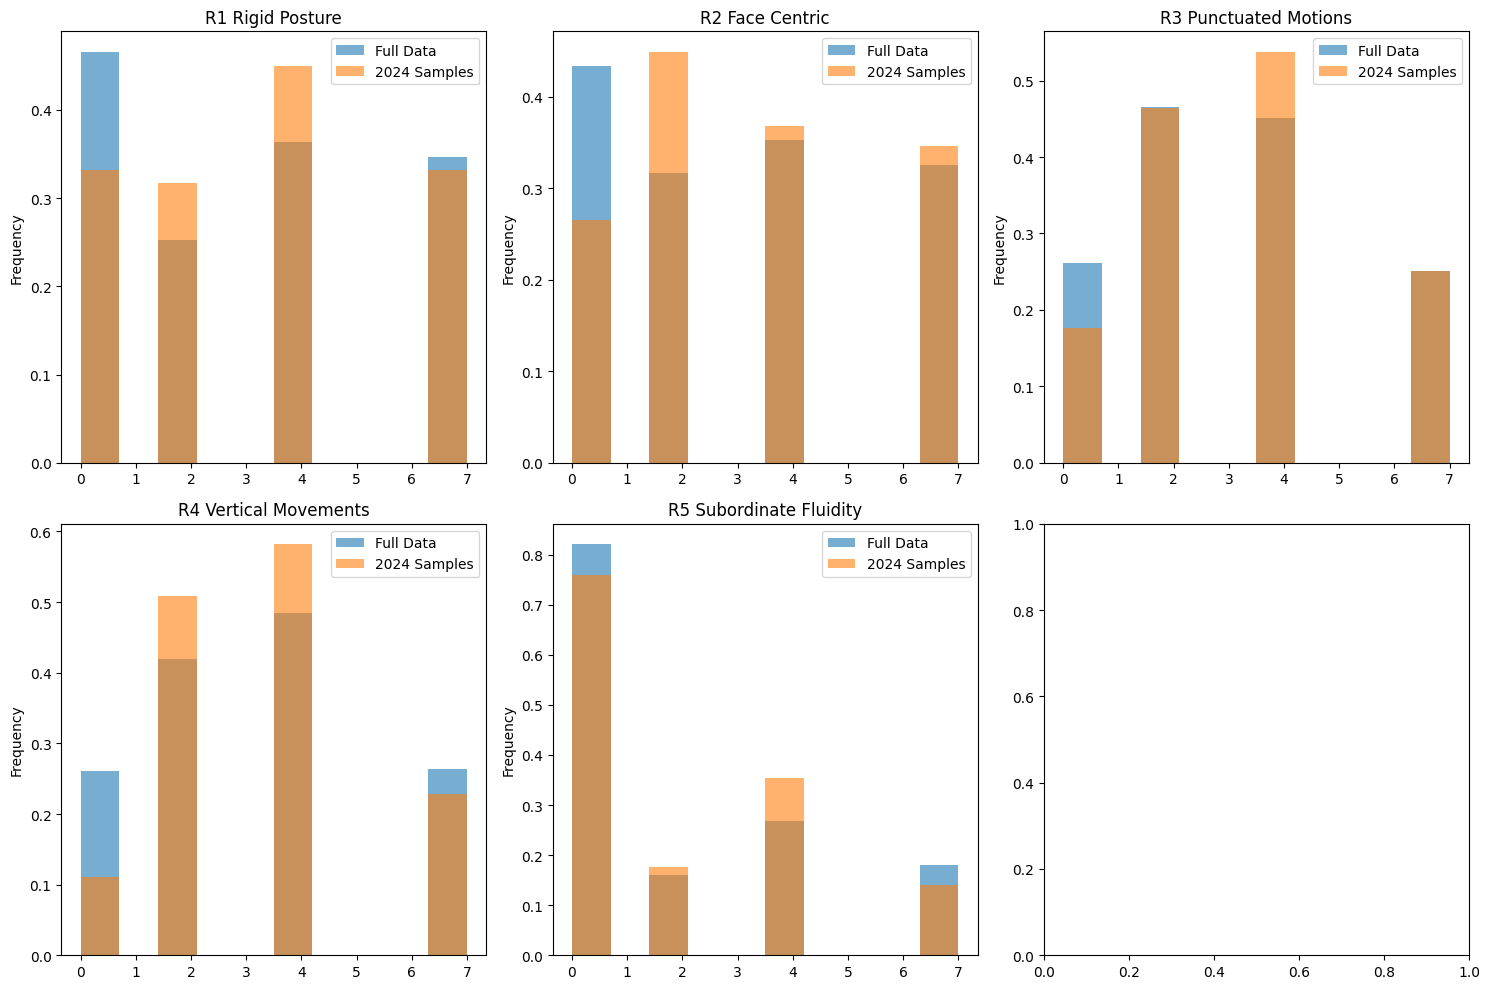

In [71]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(all_df.loc[:,'R1 Rigid Posture':'R5 Subordinate Fluidity'].columns):
    ax = axes[i]
    all_df[column].plot(kind='hist', density=True, alpha=0.6, label='Full Data', ax=ax)
    all_2024[column].plot(kind='hist', density=True, alpha=0.6, label='2024 Samples', ax=ax)
    ax.set_title(column)
    ax.legend()

plt.tight_layout()
plt.show()

The mean of these signals does seem to be increasing, but they increase less often at the extremes (even extreme highs), and tend to increase in the middle especially and to have far less frequent 0 values

### Fluid Signals <a id="FluidFD"></a>

In [72]:
all_2024.loc[:,'F1 Fluid Posture':'F5 Subordinate Rigidity'].describe()

,F1 Fluid Posture,F2 Eye Centric,F3 Gliding Motions,F4 Horizontal Movements,F5 Subordinate Rigidity
count,194.00000,194.000000,194.000000,194.000000,194.000000
mean,3.57732,3.577320,3.804124,4.520619,2.628866
std,2.31613,2.471957,2.114050,2.101588,2.610539
min,0.00000,0.000000,0.000000,0.000000,0.000000
25%,2.00000,2.000000,2.000000,4.000000,0.000000
50%,4.00000,4.000000,4.000000,4.000000,2.000000
75%,4.00000,7.000000,4.000000,7.000000,4.000000
max,7.00000,7.000000,7.000000,7.000000,7.000000


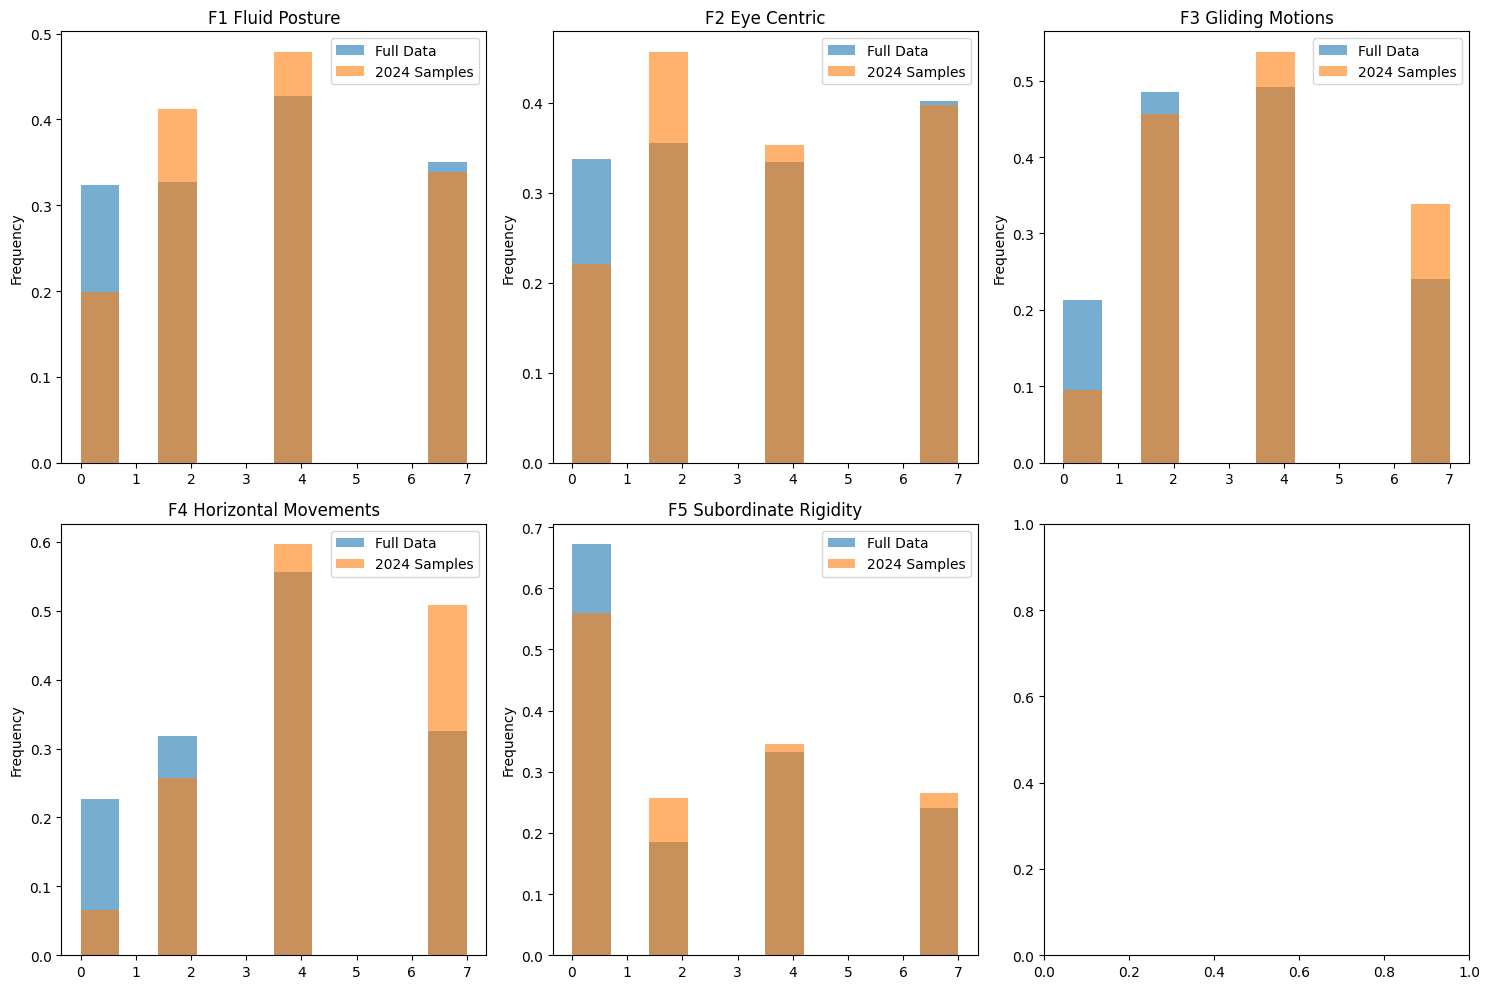

In [73]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(all_df.loc[:,'F1 Fluid Posture':'F5 Subordinate Rigidity'].columns):
    ax = axes[i]
    all_df[column].plot(kind='hist', density=True, alpha=0.6, label='Full Data', ax=ax)
    all_2024[column].plot(kind='hist', density=True, alpha=0.6, label='2024 Samples', ax=ax)
    ax.set_title(column)
    ax.legend()

plt.tight_layout()
plt.show()

Again we can see the central tendency of the data to be increasing, but this is less reliable at extreme values (high marks), so higher overall average but more middle values especially, except curiosly in the case of Horizontal movements and Gliding motions to a lesser extent which have notably more high signals

### Pe Signals <a id="PeFD"></a>

In [74]:
all_2024.loc[:,'PF1 Restless Momentum':'PF5 Alert Perk Ups'].describe()

,PF1 Restless Momentum,PF2 Toggling Eyes,PF3 Body Swaying,PF4 Casual Hands,PF5 Alert Perk Ups
count,194.000000,194.000000,194.000000,194.000000,194.000000
mean,3.067010,4.577320,4.154639,4.623711,3.376289
std,1.984563,1.999145,2.017233,2.125019,2.213396
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,4.000000,2.000000,4.000000,2.000000
50%,2.000000,4.000000,4.000000,4.000000,4.000000
75%,4.000000,7.000000,7.000000,7.000000,4.000000
max,7.000000,7.000000,7.000000,7.000000,7.000000


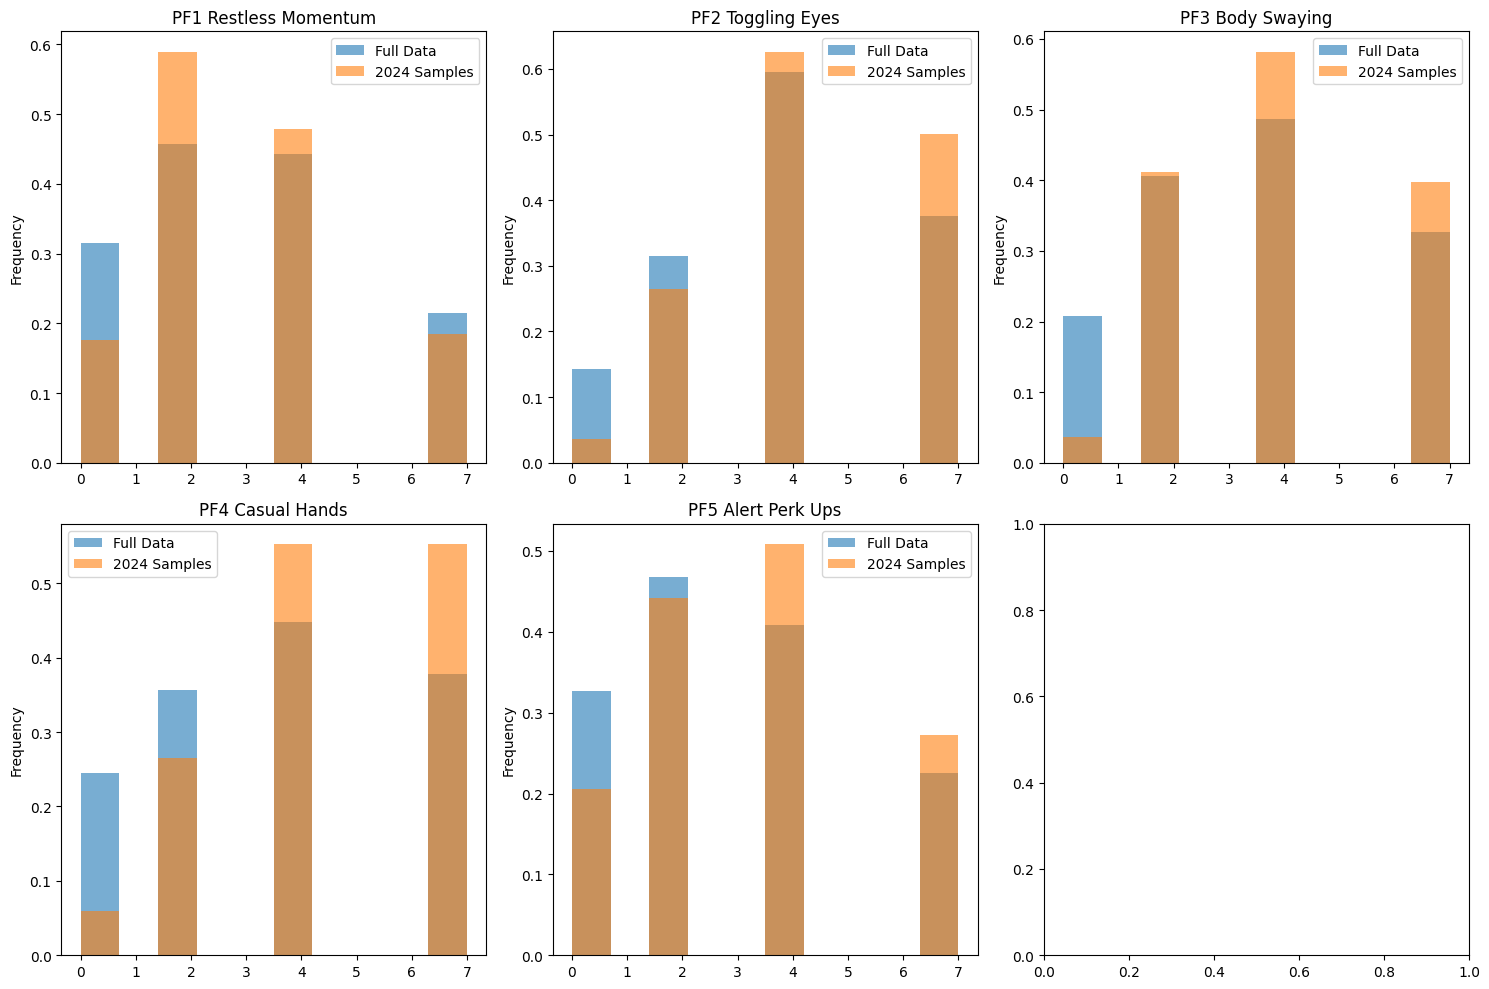

In [75]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(all_df.loc[:,'PF1 Restless Momentum':'PF5 Alert Perk Ups'].columns):
    ax = axes[i]
    all_df[column].plot(kind='hist', density=True, alpha=0.6, label='Full Data', ax=ax)
    all_2024[column].plot(kind='hist', density=True, alpha=0.6, label='2024 Samples', ax=ax)
    ax.set_title(column)
    ax.legend()

plt.tight_layout()
plt.show()

Again there is the very consistent theme of having far less frequent 0 markings, and more frequent middle markings and in this case mostly more frequent high markings as well

### Pi Signals <a id="PiFD"></a>

In [76]:
all_2024.loc[:,'RF1 Viscous Inertia':'RF5 Narrow Head Zoning'].describe()

,RF1 Viscous Inertia,RF2 Fixed Gaze,RF3 Diagonal Eye Drifts,RF4 Searching Scowling,RF5 Narrow Head Zoning
count,194.000000,194.000000,194.000000,194.000000,194.000000
mean,2.175258,2.737113,3.092784,2.293814,2.211340
std,2.223335,2.194662,1.929227,1.871871,2.246857
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,2.000000,2.000000,0.000000
50%,2.000000,2.000000,2.000000,2.000000,2.000000
75%,4.000000,4.000000,4.000000,4.000000,4.000000
max,7.000000,7.000000,7.000000,7.000000,7.000000


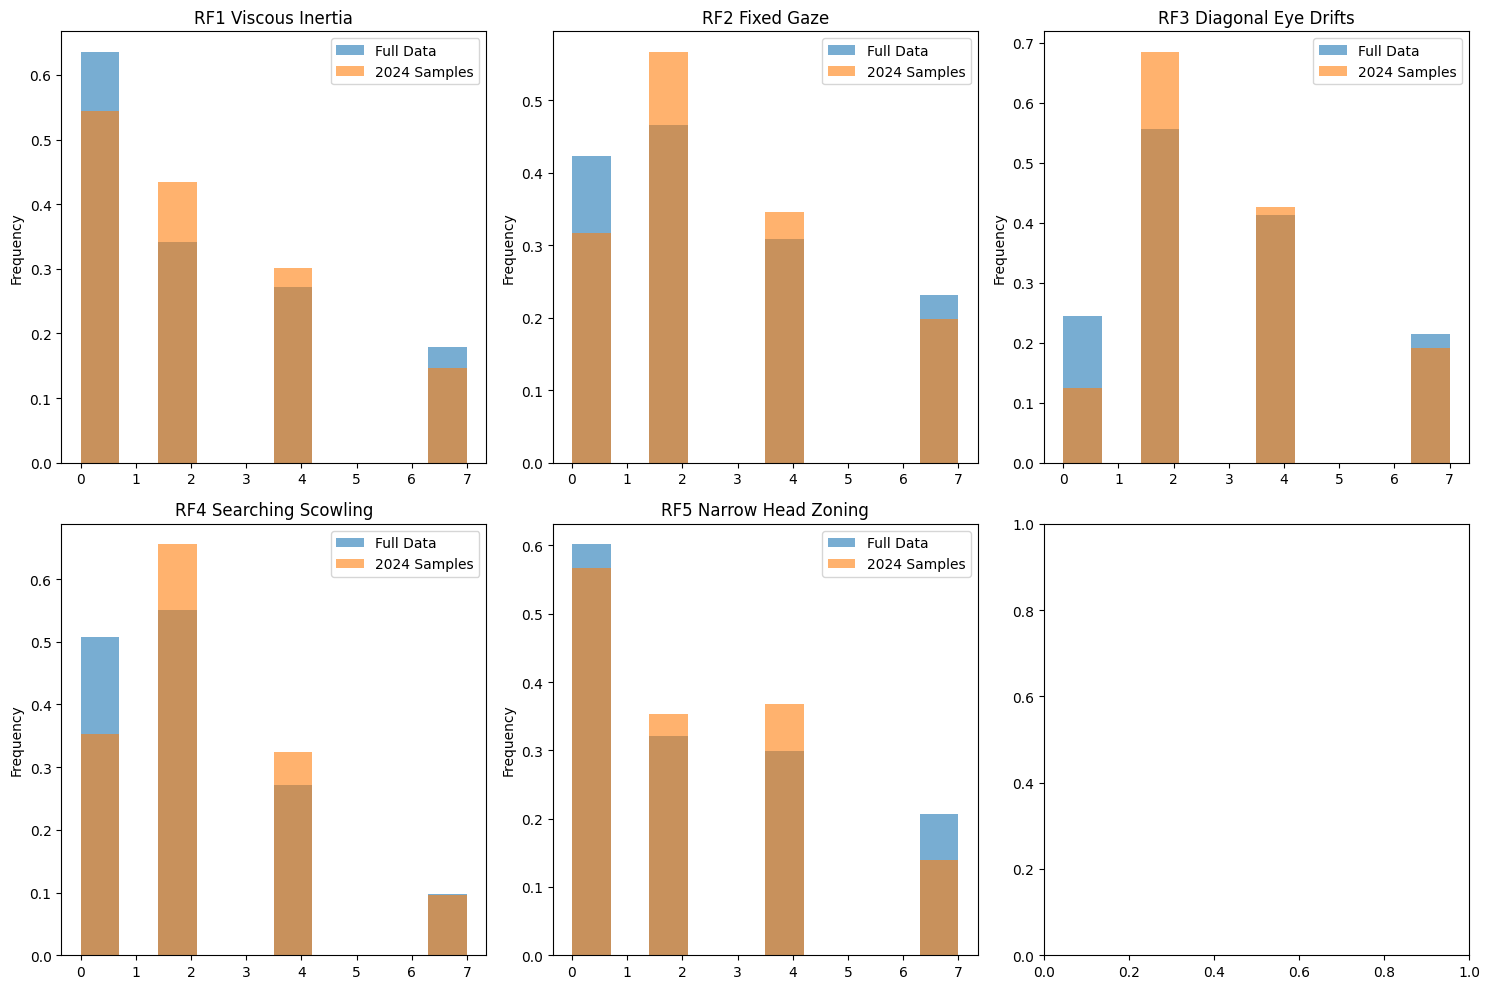

In [77]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(all_df.loc[:,'RF1 Viscous Inertia':'RF5 Narrow Head Zoning'].columns):
    ax = axes[i]
    all_df[column].plot(kind='hist', density=True, alpha=0.6, label='Full Data', ax=ax)
    all_2024[column].plot(kind='hist', density=True, alpha=0.6, label='2024 Samples', ax=ax)
    ax.set_title(column)
    ax.legend()

plt.tight_layout()
plt.show()

There is an increased mean in this case as well due to fewer 0 markings but seemingly not by as much since Pi isn't as common of an energetic in celebrities, and there are no increases (and often slight decreases) of high markings for Pi

### Je Signals <a id="JeFD"></a>

In [78]:
all_2024.loc[:,'PR1 Head Pushes':'PR5 Projecting Hands'].describe()

,PR1 Head Pushes,PR2 Head Shakes,PR3 Shoulder Shrugs,PR4 Fluent Articulation,PR5 Projecting Hands
count,194.000000,194.000000,194.000000,194.000000,194.000000
mean,3.927835,3.469072,2.350515,4.443299,4.701031
std,2.242997,2.089096,1.663639,2.056049,2.184092
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000,4.000000,4.000000
50%,4.000000,4.000000,2.000000,4.000000,4.000000
75%,7.000000,4.000000,4.000000,7.000000,7.000000
max,7.000000,7.000000,7.000000,7.000000,7.000000


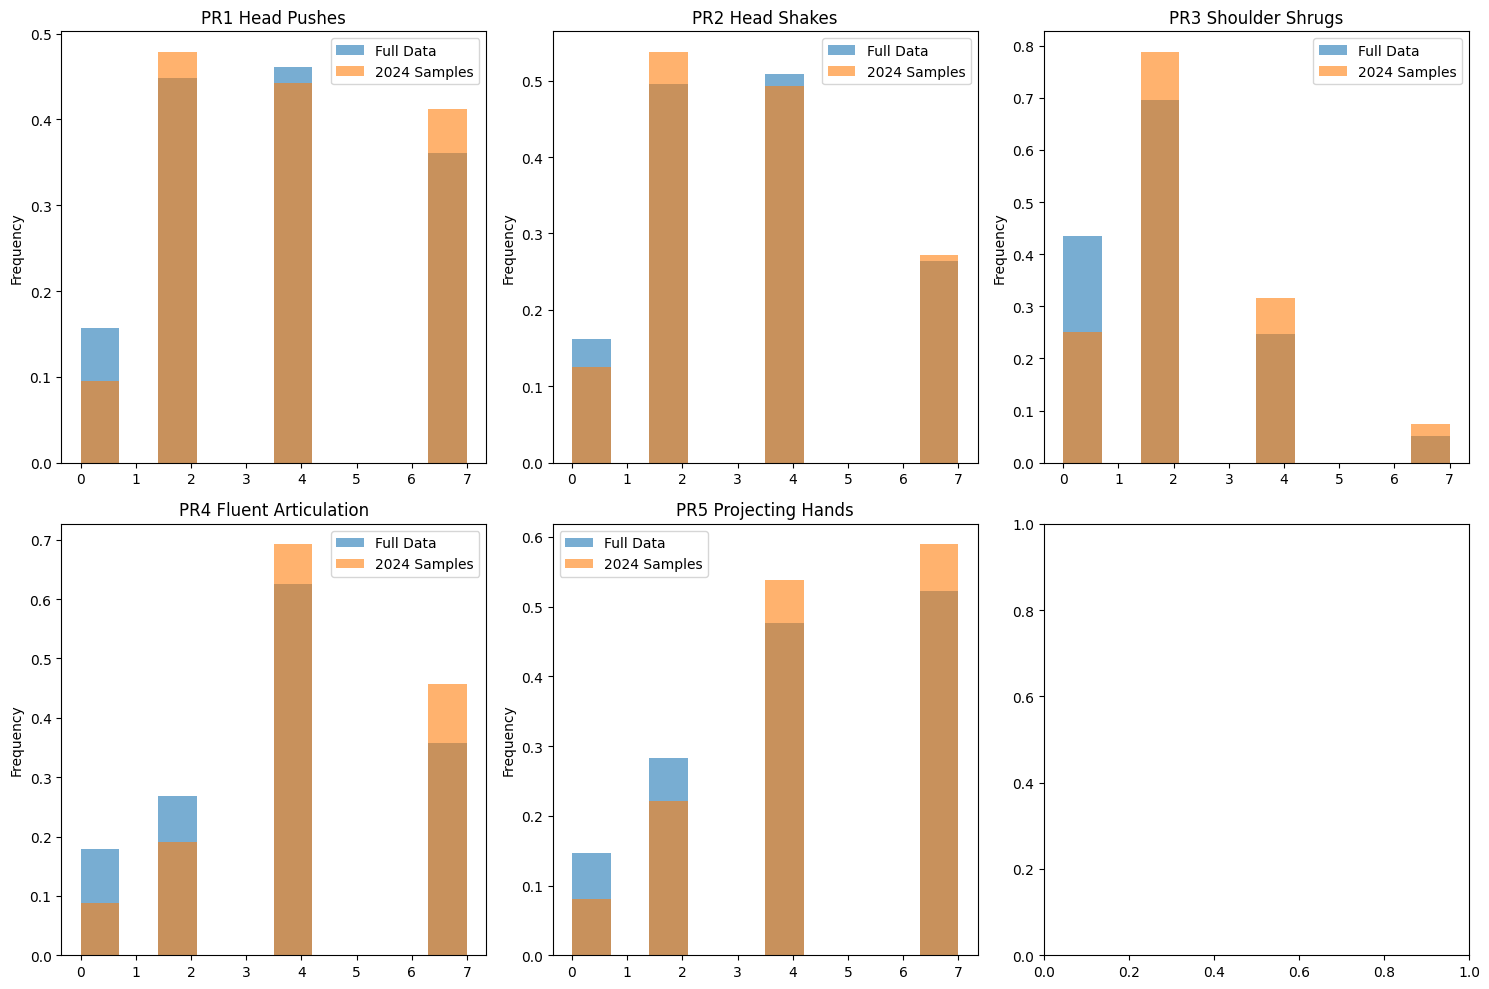

In [79]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(all_df.loc[:,'PR1 Head Pushes':'PR5 Projecting Hands'].columns):
    ax = axes[i]
    all_df[column].plot(kind='hist', density=True, alpha=0.6, label='Full Data', ax=ax)
    all_2024[column].plot(kind='hist', density=True, alpha=0.6, label='2024 Samples', ax=ax)
    ax.set_title(column)
    ax.legend()

plt.tight_layout()
plt.show()

It's interesting that there is specifically less frequent Mid signals for both Head Pushes and Head Shakes, but as with Pe signals, Je signals seem to increase higher markings mostly across the board

### Ji Signals <a id="JiFD"></a>

In [80]:
all_2024.loc[:,'RR1 Poised Receding':'RR5 Meticulous Hands'].describe()

,RR1 Poised Receding,RR2 Disengaging Eyes,RR3 Exerted Pushes,RR4 Momentum Halting,RR5 Meticulous Hands
count,194.000000,194.000000,194.000000,194.000000,194.000000
mean,2.984536,3.293814,2.108247,2.108247,3.953608
std,2.231375,2.010661,1.787589,1.555080,2.160146
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,0.000000,2.000000,2.000000
50%,2.000000,4.000000,2.000000,2.000000,4.000000
75%,4.000000,4.000000,4.000000,2.000000,7.000000
max,7.000000,7.000000,7.000000,7.000000,7.000000


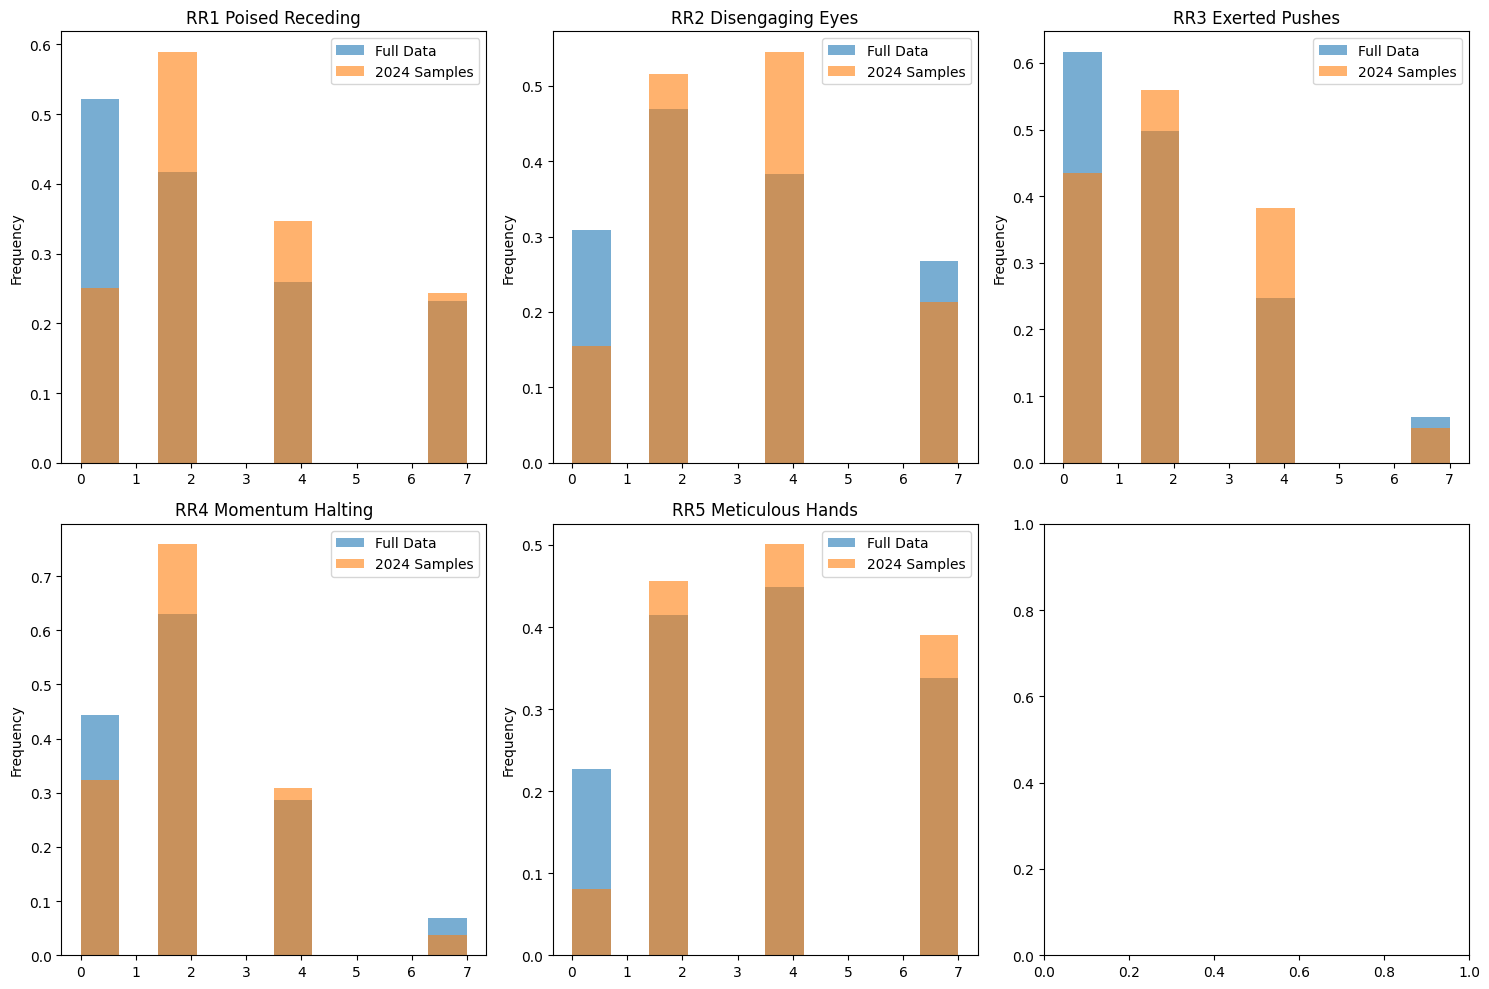

In [81]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(all_df.loc[:,'RR1 Poised Receding':'RR5 Meticulous Hands'].columns):
    ax = axes[i]
    all_df[column].plot(kind='hist', density=True, alpha=0.6, label='Full Data', ax=ax)
    all_2024[column].plot(kind='hist', density=True, alpha=0.6, label='2024 Samples', ax=ax)
    ax.set_title(column)
    ax.legend()

plt.tight_layout()
plt.show()

As with Pi Signals, the increased central tendency of these distributions is more moderate, mainly due to fewer increases of high signals (they mostly slightly decrease in frequency), but there are consistently more low and mid signals and far fewer 0 markings

### Candid Signals <a id="CandidFD"></a>

In [82]:
all_2024.loc[:,'CA1 Taut Nasolabial Area':'CA9 Grasping Hands'].describe()

,CA1 Taut Nasolabial Area,CA2 Vertical Snarling Smiles,CA3 Four Point Pulling,CA4 Wobbling Lips,CA5 Asymmetrical Smirks,CA6 Sassy Movements,CA7 Plateau Velocity,CA8 Nasal Breathy Voice,CA9 Grasping Hands
count,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000
mean,2.680412,2.170103,2.860825,2.639175,1.762887,2.201031,2.273196,1.381443,1.268041
std,2.235124,2.534106,2.542124,2.119173,1.919484,2.311449,2.359547,2.199592,1.890886
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0.000000,0.000000
75%,4.000000,4.000000,4.000000,4.000000,2.000000,4.000000,4.000000,2.000000,2.000000
max,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000


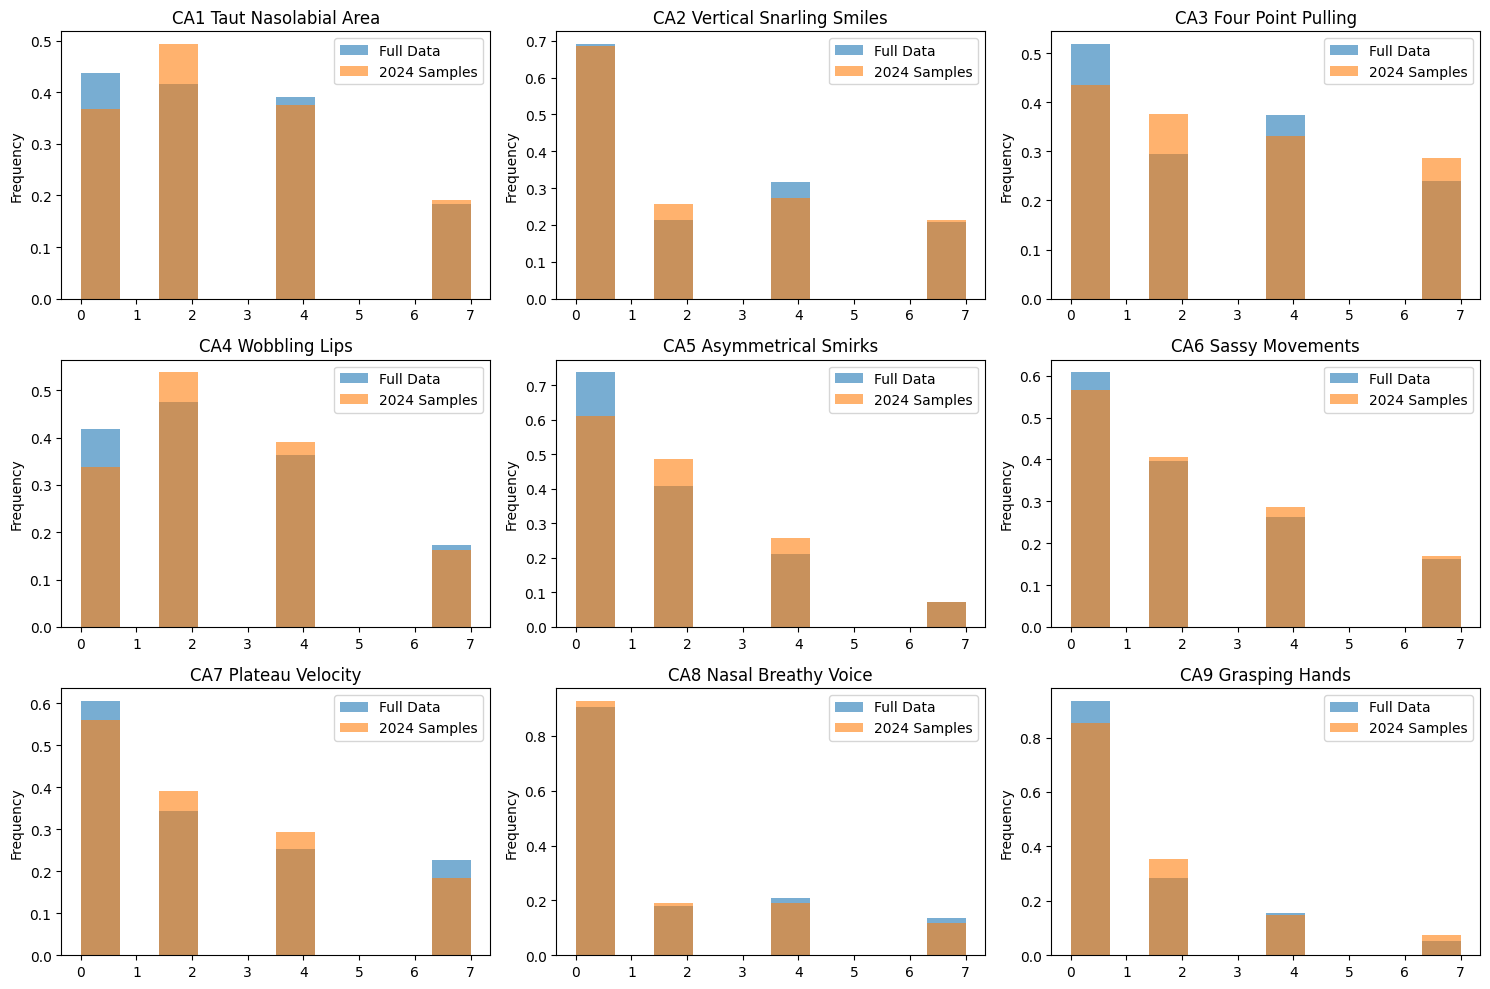

In [83]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(all_df.loc[:,'CA1 Taut Nasolabial Area':'CA9 Grasping Hands'].columns):
    ax = axes[i]
    all_df[column].plot(kind='hist', density=True, alpha=0.6, label='Full Data', ax=ax)
    all_2024[column].plot(kind='hist', density=True, alpha=0.6, label='2024 Samples', ax=ax)
    ax.set_title(column)
    ax.legend()

plt.tight_layout()
plt.show()

There aren't as many changes in this set of signals, but there is still consistently less frequent 0 markings, and often more mid and low signals

### Measured Signals <a id="MeasuredFD"></a>

In [84]:
all_2024.loc[:,'MS1 Lax Nasolabial Area':'MS9 Puppeteer Hands'].describe()

,MS1 Lax Nasolabial Area,MS2 Horizontal Curtain Smiles,MS3 Two Point Pulling,MS4 Symmetrical Lips,MS5 Emotional Neutralization,MS6 Coordinated Movements,MS7 Parabolic Velocity,MS8 Laryngeal Faint Voice,MS9 Puppeteer Hands
count,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000
mean,2.561856,3.969072,3.567010,3.567010,2.994845,3.422680,3.793814,3.025773,2.046392
std,2.349907,2.798792,2.687169,2.455436,2.364455,2.194364,2.505696,2.754997,2.118977
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.500000,2.000000,2.000000,2.000000,2.000000,0.000000,0.000000
50%,2.000000,4.000000,4.000000,4.000000,2.000000,4.000000,4.000000,2.000000,2.000000
75%,4.000000,7.000000,7.000000,4.000000,4.000000,4.000000,7.000000,6.250000,4.000000
max,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000


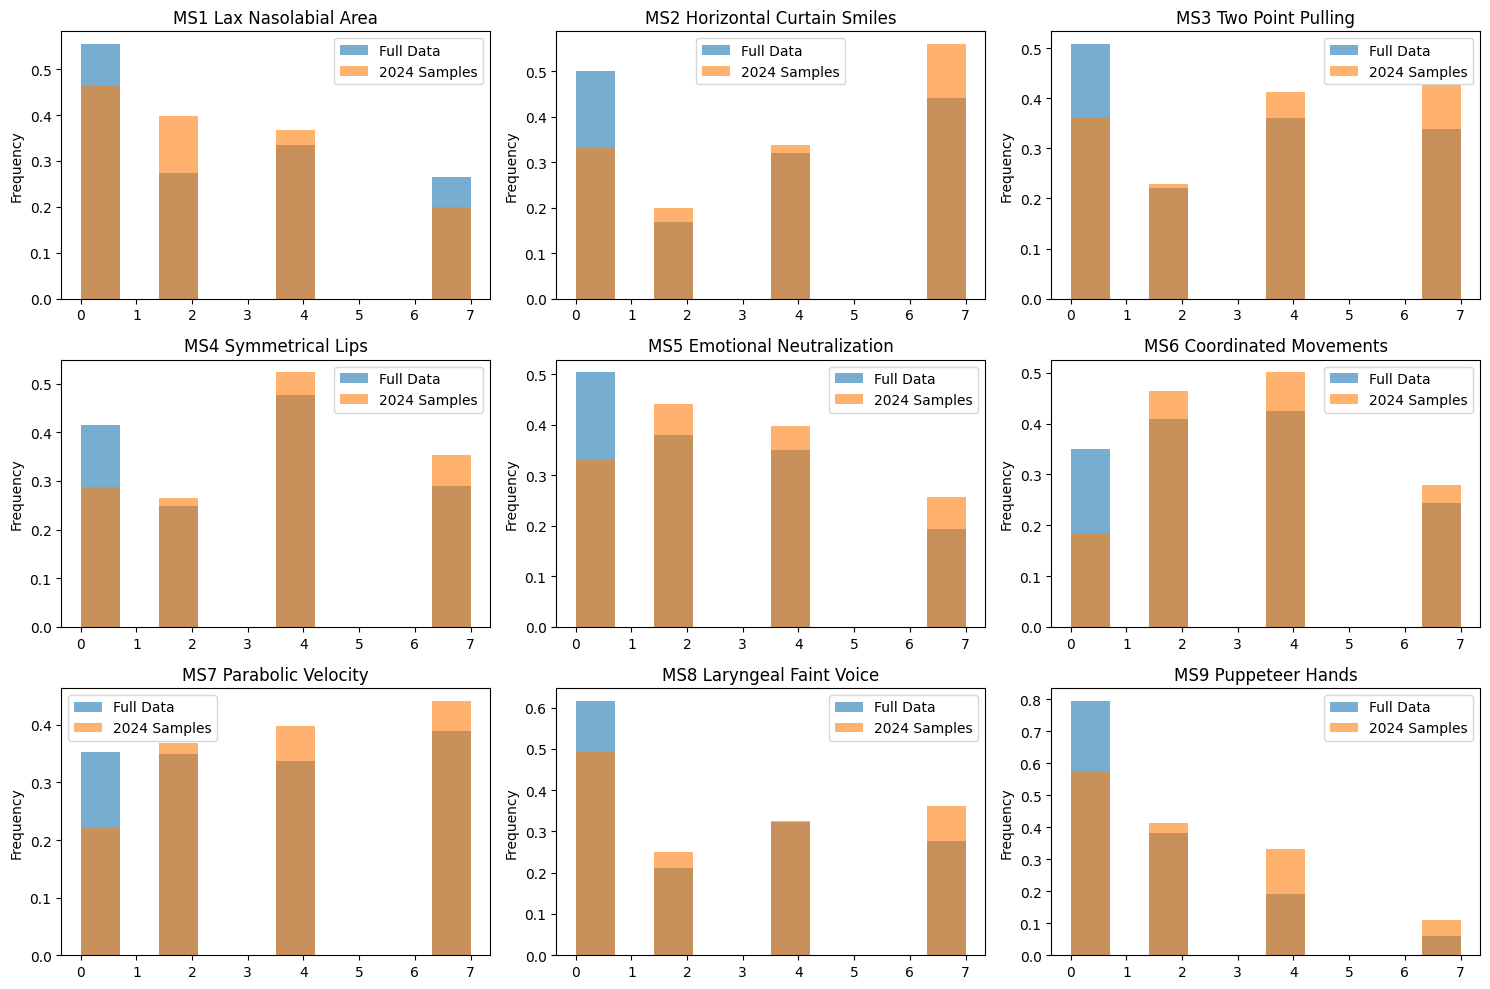

In [85]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(all_df.loc[:,'MS1 Lax Nasolabial Area':'MS9 Puppeteer Hands'].columns):
    ax = axes[i]
    all_df[column].plot(kind='hist', density=True, alpha=0.6, label='Full Data', ax=ax)
    all_2024[column].plot(kind='hist', density=True, alpha=0.6, label='2024 Samples', ax=ax)
    ax.set_title(column)
    ax.legend()

plt.tight_layout()
plt.show()

It's a similar story to the Candid signals but more extreme and a higher shift in central tendency, with notably more high signals. This makes sense given that we had even more SeTi and Fe leads than before, but a notable amount

### Grounded Signals <a id="GroundedFD"></a>

In [86]:
all_2024.loc[:,'GR1 Taut Preseptal Area':'GR8 Bodily Awareness'].describe()

,GR1 Taut Preseptal Area,GR2 Lax Pretarsal Area,GR3 Taut Outer Edges,GR4 Intense Scowling,GR5 Pointed Eye Toggles,GR6 Eye Head Parallel Motion,GR7 Grounding Effect,GR8 Bodily Awareness
count,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000
mean,3.298969,2.798969,3.551546,2.288660,3.979381,3.242268,2.737113,2.603093
std,2.383731,2.324860,2.658435,2.438715,2.385098,2.511748,2.329794,2.249281
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.500000,2.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,4.000000,2.000000,4.000000,2.000000,4.000000,4.000000,2.000000,2.000000
75%,4.000000,4.000000,7.000000,4.000000,7.000000,4.000000,4.000000,4.000000
max,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000


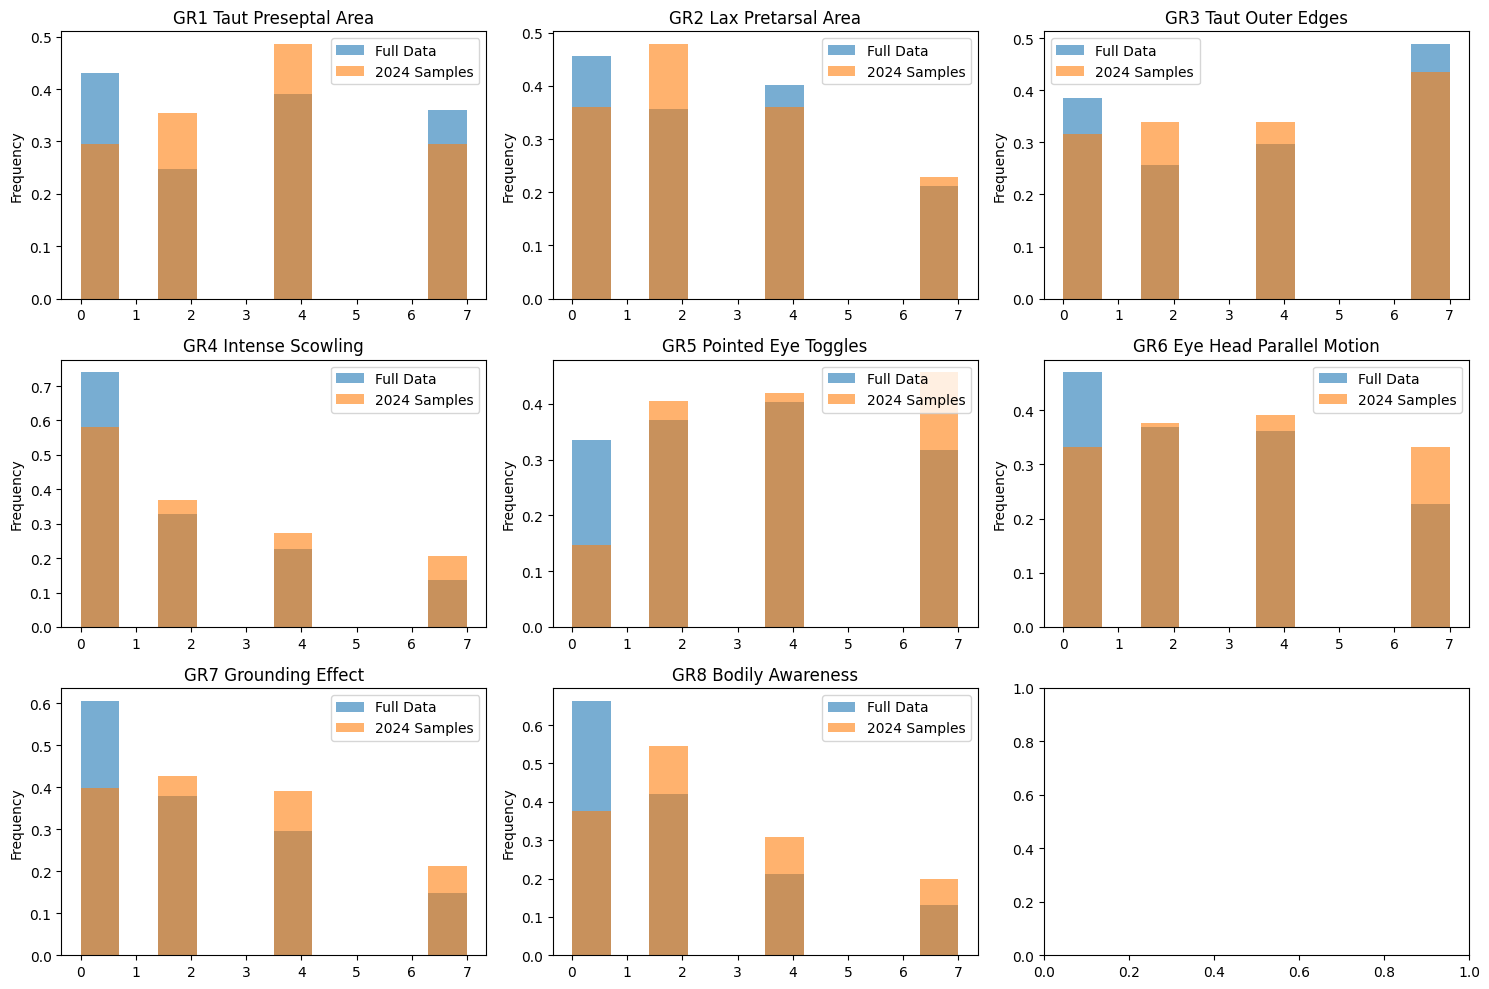

In [87]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(all_df.loc[:,'GR1 Taut Preseptal Area':'GR8 Bodily Awareness'].columns):
    ax = axes[i]
    all_df[column].plot(kind='hist', density=True, alpha=0.6, label='Full Data', ax=ax)
    all_2024[column].plot(kind='hist', density=True, alpha=0.6, label='2024 Samples', ax=ax)
    ax.set_title(column)
    ax.legend()

plt.tight_layout()
plt.show()

It's more similar to Measured since it's one of the more common quadra signals

### Suspended Signals <a id="SuspendedFD"></a>

In [88]:
all_2024.loc[:,'SU1 Lax Preseptal Area':'SU8 Quirky Skits'].describe()

,SU1 Lax Preseptal Area,SU2 Taut Pretarsal Area,SU3 Lax Outer Edges,SU4 Concerned Scowling,SU5 Brushstrokes Eye Toggles,SU6 Eye Head Trailing Motions,SU7 Levity Effect,SU8 Quirky Skits
count,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000
mean,2.845361,3.067010,2.577320,2.329897,2.463918,1.190722,1.592784,1.257732
std,2.550384,2.581449,2.564545,2.441955,2.303689,1.609466,1.972387,1.975384
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,2.000000,2.000000,2.000000,2.000000,0.000000,1.000000,0.000000
75%,4.000000,4.000000,4.000000,4.000000,4.000000,2.000000,2.000000,2.000000
max,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000


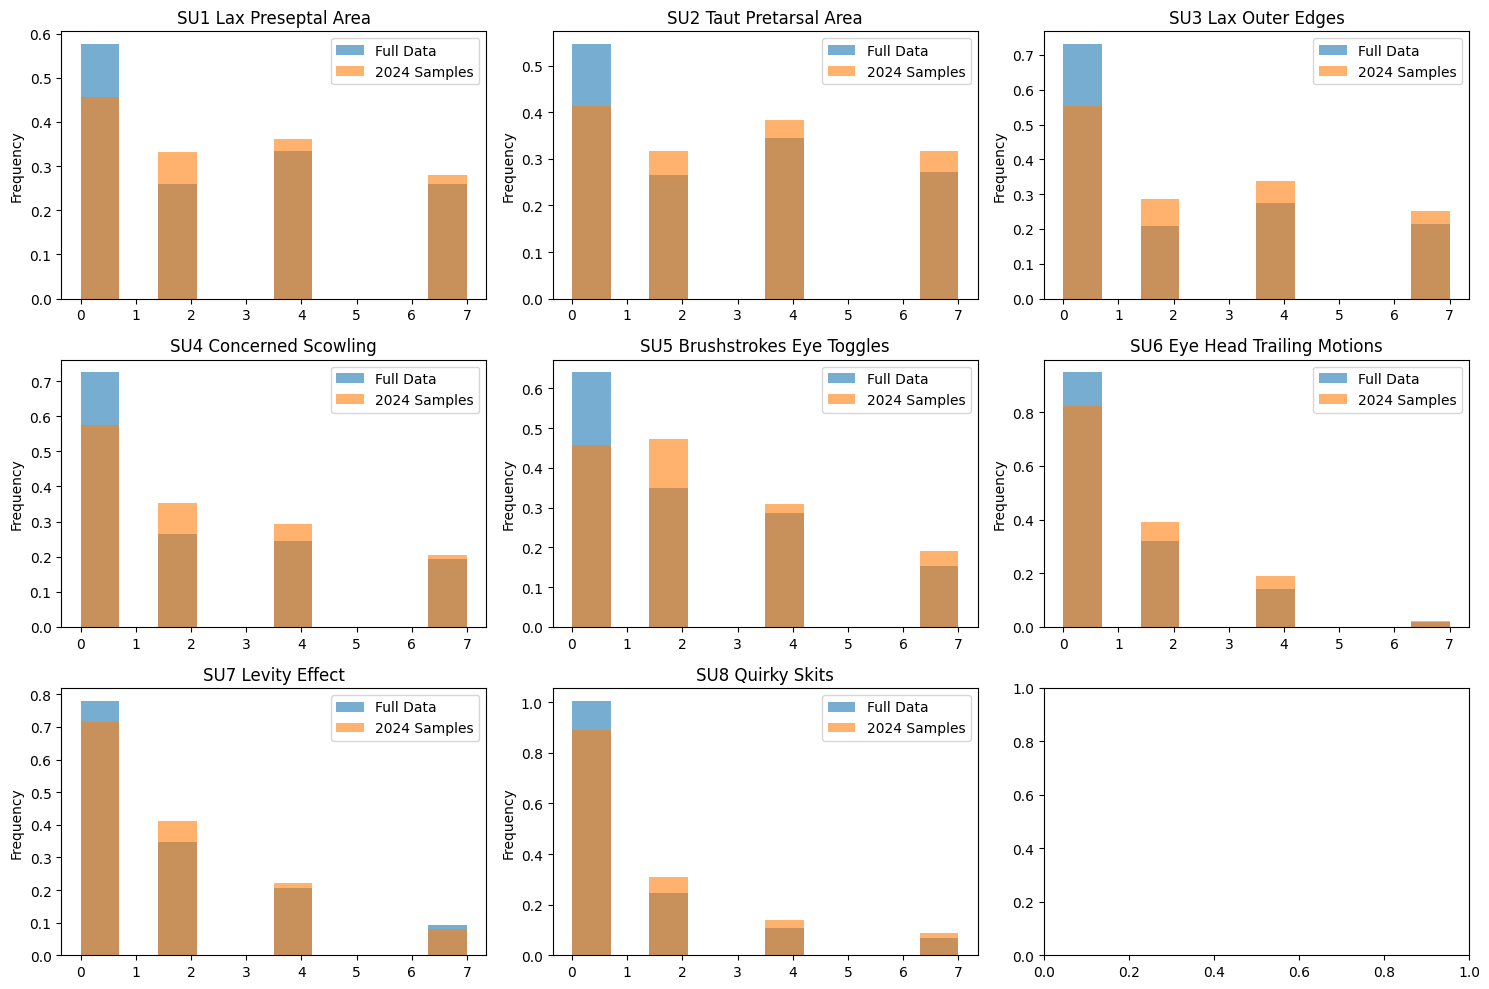

In [89]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(all_df.loc[:,'SU1 Lax Preseptal Area':'SU8 Quirky Skits'].columns):
    ax = axes[i]
    all_df[column].plot(kind='hist', density=True, alpha=0.6, label='Full Data', ax=ax)
    all_2024[column].plot(kind='hist', density=True, alpha=0.6, label='2024 Samples', ax=ax)
    ax.set_title(column)
    ax.legend()

plt.tight_layout()
plt.show()

Interestingly this is also more similar to Measured and Grounded, not to the same extent but with mostly greater frequencies even in high signals and very consistently across all levels. This may be because Candid had the biggest dive in frequency of all quadra signals even though it isn't actually the lowest, since we had increases in Beta and Alpha which goes along with decreases in both Gamma and Delta

### Unguarded Signals <a id="UnguardedFD"></a>

In [90]:
all_2024.loc[:,'EU1 Responsive Nodding':'EU3 Bashful Body Movements'].describe()

,EU1 Responsive Nodding,EU2 Polite Smiling,EU3 Bashful Body Movements
count,194.000000,194.000000,194.000000
mean,2.819588,3.448454,1.963918
std,2.011219,2.161827,2.191301
min,0.000000,0.000000,0.000000
25%,2.000000,2.000000,0.000000
50%,2.000000,4.000000,2.000000
75%,4.000000,4.000000,4.000000
max,7.000000,7.000000,7.000000


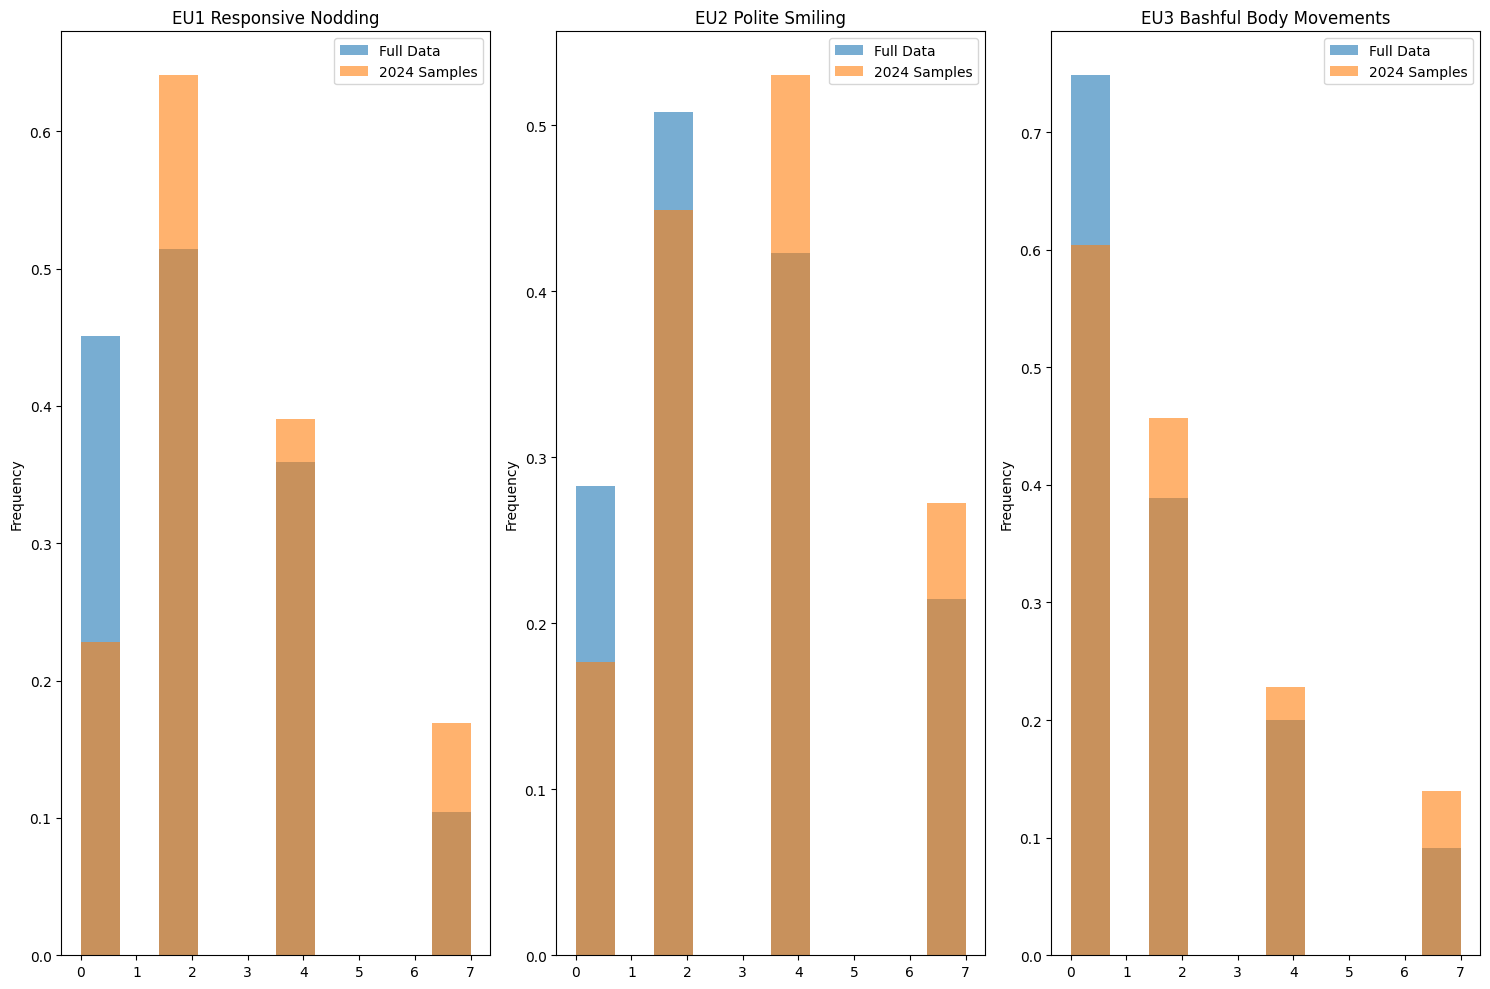

In [91]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(all_df.loc[:,'EU1 Responsive Nodding':'EU3 Bashful Body Movements'].columns):
    ax = axes[i]
    all_df[column].plot(kind='hist', density=True, alpha=0.6, label='Full Data', ax=ax)
    all_2024[column].plot(kind='hist', density=True, alpha=0.6, label='2024 Samples', ax=ax)
    ax.set_title(column)
    ax.legend()

plt.tight_layout()
plt.show()

Higher values are consistently marked more frequently for all 3 signals

### Guarded Signals <a id="GuardedFD"></a>

In [92]:
all_2024.loc[:,'EG1 Upset Mouth Tension':'EG3 Stern Expressions'].describe()

,EG1 Upset Mouth Tension,EG2 Assertive Pushing,EG3 Stern Expressions
count,194.000000,194.000000,194.000000
mean,1.371134,1.938144,2.298969
std,1.630789,2.134418,2.008608
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,2.000000,2.000000,2.000000
75%,2.000000,4.000000,4.000000
max,7.000000,7.000000,7.000000


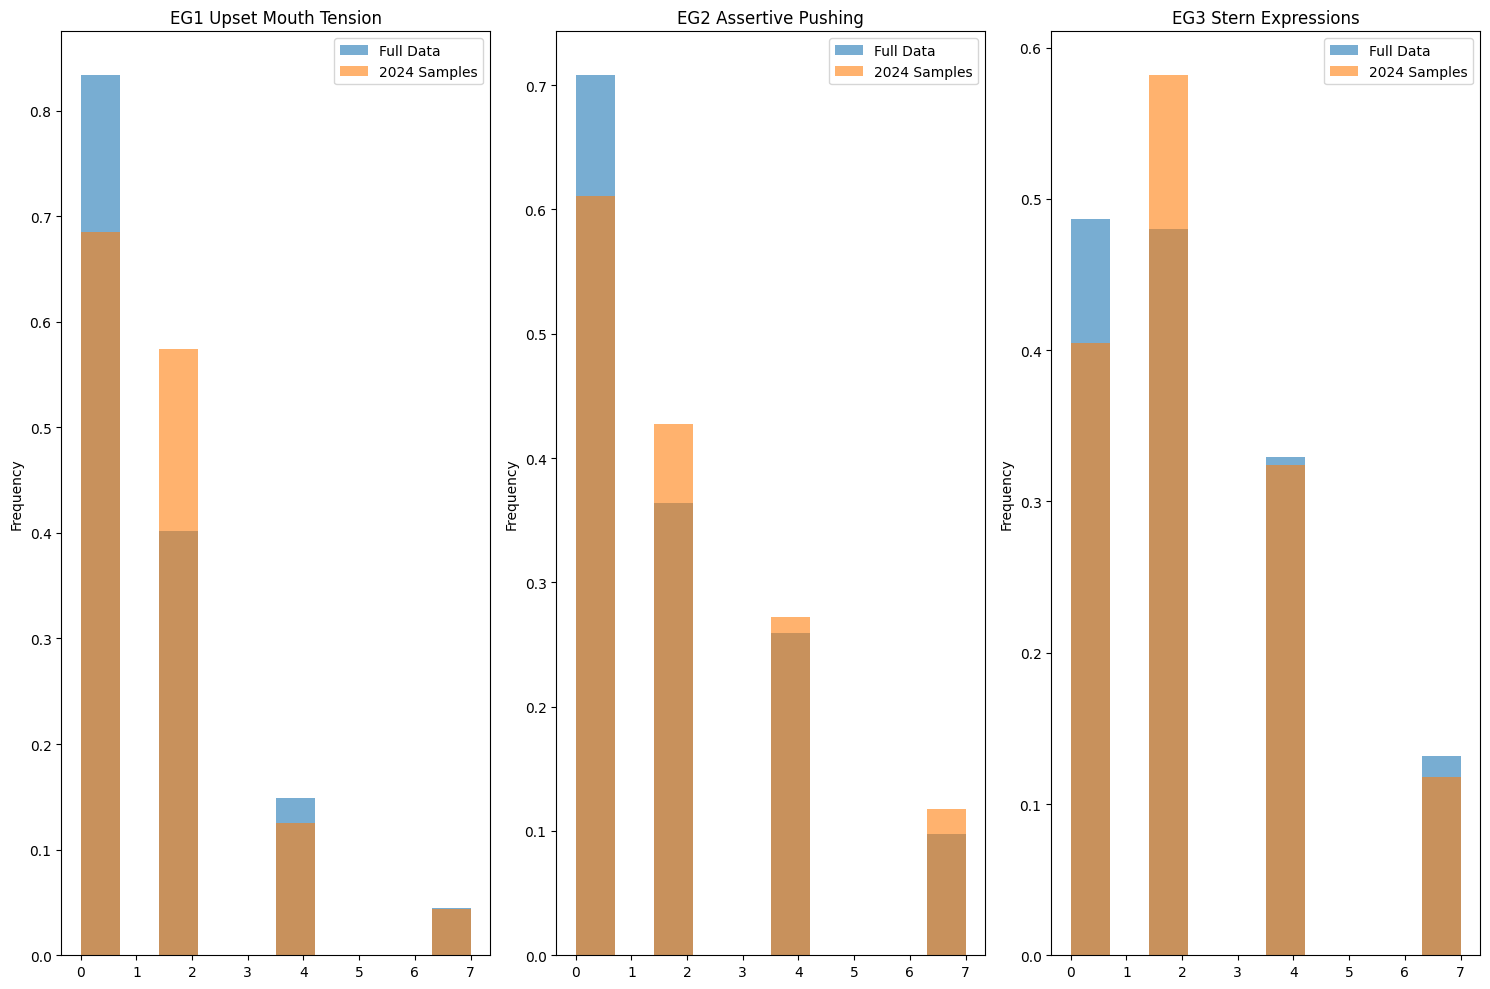

In [93]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(all_df.loc[:,'EG1 Upset Mouth Tension':'EG3 Stern Expressions'].columns):
    ax = axes[i]
    all_df[column].plot(kind='hist', density=True, alpha=0.6, label='Full Data', ax=ax)
    all_2024[column].plot(kind='hist', density=True, alpha=0.6, label='2024 Samples', ax=ax)
    ax.set_title(column)
    ax.legend()

plt.tight_layout()
plt.show()

There is a notable increase in Assertive Pushing in comparison to the other signals, but the other signals still have a small degree of increased central tendency because of less frequent 0 markings and notably more frequent low markings of signals

There is a consistent overall theme in all of these groups of signals: much less frequent 0 markings leading to an overall increased central tendency. Within that, there are some more nuanced differences in the 2024 samples, such as some signals having increased high markings, some signals having marginally decreased frequency of high markings (although the decrease is almost never by a lot and tends to be quite small), and it is very frequent for the low and mid markings to see an increase in frequency for all signals.

With that summary, we can move on to the other cuts of the data, although I don't think we'll have to look at those in as much detail because we only need to look at distributions that were originally changed in comparison to the full data in those cuts.

## Lapis Cut Samples Since 2024 <a id="Lapis2024"></a>

In [94]:
lapis_df = pd.read_csv('../Data/posts_2024-12-29_LapisCut.csv', index_col=0)
lapis_df.reset_index(drop=True, inplace=True)
lapis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 87 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Sample Name                    373 non-null    object 
 1   Vultologist                    373 non-null    object 
 2   Type                           373 non-null    object 
 3   Development                    373 non-null    object 
 4   Emotions                       373 non-null    object 
 5   Fallen Affect                  373 non-null    float64
 6   Sex                            373 non-null    object 
 7   Age Range                      373 non-null    object 
 8   Geography                      373 non-null    object 
 9   Ethnicity                      373 non-null    object 
 10  R1 Rigid Posture               373 non-null    float64
 11  R2 Face Centric                373 non-null    float64
 12  R3 Punctuated Motions          373 non-null    flo

As before, Russell Brand is the first sample typed in 2024, so we need to figure out the index of Russell Brand in this dataframe

In [95]:
lapis_df[lapis_df["Sample Name"] == "Russell Brand"]

,Sample Name,Vultologist,Type,Development,Emotions,Fallen Affect,Sex,Age Range,Geography,Ethnicity,...,EG1 Upset Mouth Tension,EG2 Assertive Pushing,EG3 Stern Expressions,sum,Lead Energetic,Quadra,Emotion_Val,Emotion_RawDiff,J_Signal_Mixing,P_Signal_Mixing
122,Russell Brand,Sierra Schwartz,feni,i-i-,guarded,0.0,male,1970s,western_europe,white/european,...,4.0,7.0,4.0,198.0,Je,Beta,0.428571,9.0,0.48,0.588235


In [96]:
lapis_2024 = lapis_df.iloc[0:123]
lapis_2024.tail()

,Sample Name,Vultologist,Type,Development,Emotions,Fallen Affect,Sex,Age Range,Geography,Ethnicity,...,EG1 Upset Mouth Tension,EG2 Assertive Pushing,EG3 Stern Expressions,sum,Lead Energetic,Quadra,Emotion_Val,Emotion_RawDiff,J_Signal_Mixing,P_Signal_Mixing
118,Amalie Bruun,Calin Copil,fine,ii-i,neutral,2.0,female,1980s,western_europe,white/european,...,2.0,2.0,4.0,216.0,Ji,Delta,0.000000,0.0,0.857143,0.410256
119,Sam Kerr,Calin Copil,sefi,i---,neutral,1.0,female,1990s,australia/new_zeland,other/unknown,...,2.0,0.0,2.0,174.0,Pe,Gamma,-0.333333,-4.0,0.526316,0.512821
120,Barry Keoghan,Calin Copil,seti,i---,unguarded,0.0,male,1990s,western_europe,-1,...,2.0,0.0,2.0,171.0,Pe,Beta,-0.428571,-6.0,0.761905,0.137931
121,Ashley Graham,Calin Copil,feni,i-i-,unguarded,0.0,female,1980s,north_america,white/european,...,0.0,2.0,4.0,195.0,Je,Beta,-0.333333,-6.0,0.571429,0.625000
122,Russell Brand,Sierra Schwartz,feni,i-i-,guarded,0.0,male,1970s,western_europe,white/european,...,4.0,7.0,4.0,198.0,Je,Beta,0.428571,9.0,0.480000,0.588235


There are 123 samples, and we can get started with the tests, remembering that we only really need to look at the features in the Lapis Cut which were significantly different

## Kolmogorov-Smirnov Tests <a id="KSLC"></a>

In [97]:
KS_cols = ['J_Signal_Mixing', 'P_Signal_Mixing']

KS_results = {}

for col in KS_cols:
    stat, p_value = ks_2samp(lapis_df[col], lapis_2024[col])
    KS_results[col] = {'statistic': stat, 'p_value': p_value.round(3)}

KS_df = pd.DataFrame.from_dict(KS_results)
KS_df.transpose()

,statistic,p_value
J_Signal_Mixing,0.066065,0.783
P_Signal_Mixing,0.076091,0.624


Notably there isn't a statistically significant difference between the lapis cut (which was designed to remove samples with 0 or very low signal mixing) and its subset in 2024. As Lapis himself pointed out, there have been more efforts in 2024 to mark more signals in general even if they oppose the resultant type dichotomies. Since both the Lapis cut and the sample reports of 2024 make efforts in this direction, it's not surprising that they achieve resultant distributions that are so similar as to not have statistically significant differences. It also shows that efforts taken in 2024 to mark more signals are leading to higher values of signal mixing (in addition to increasing general mean frequencies of signals as we already saw).

## Mann-Whitney Tests <a id="MWLC"></a>

In [98]:
MW_cols = [col for col in list(lapis_2024.columns) if (col not in KS_cols) and (col not in ['Sample Name', 'Vultologist', 'sum', 'Emotion_Val', 'Emotion_RawDiff'])]

MW_results = {}

for col in MW_cols:
    if lapis_df[col].dtype == 'O':
        stat, p_value = mannwhitneyu(lapis_df[col].value_counts(), lapis_2024[col].value_counts())
    else:
        stat, p_value = mannwhitneyu(lapis_df[col], lapis_2024[col])
    MW_results[col] = {'statistic': stat, 'p_value': p_value.round(3)}

MW_df = pd.DataFrame.from_dict(MW_results)
with pd.option_context("display.max_rows", 1000):
    print(MW_df.transpose().sort_values('p_value'))

                               statistic  p_value
Type                               248.0    0.000
PF4 Casual Hands                 18384.5    0.001
Development                         62.0    0.002
F4 Horizontal Movements          19075.0    0.003
PR4 Fluent Articulation          19453.5    0.007
MS9 Puppeteer Hands              19562.0    0.008
GR8 Bodily Awareness             19565.5    0.009
RR1 Poised Receding              19702.5    0.015
SU3 Lax Outer Edges              20032.5    0.026
Lead Energetic                      16.0    0.029
Quadra                              16.0    0.029
GR7 Grounding Effect             20168.5    0.034
PF2 Toggling Eyes                20230.0    0.036
SU5 Brushstrokes Eye Toggles     20344.0    0.050
MS3 Two Point Pulling            20399.0    0.056
SU2 Taut Pretarsal Area          20467.5    0.064
Age Range                           96.0    0.069
PR3 Shoulder Shrugs              20675.0    0.074
F3 Gliding Motions               20654.0    0.081


By comparison to the full data, there are far fewer statistically significant differences produced by narrowing the scope of the Lapis Cut to 2024, but there are still some we can look at:
- Fluid
- Pe
- Je
- Ji
- Measured
- Grounded
- Suspended

We don't need to look at categorical variables like Type, Development, Lead Energetic, Quadra, Age Range and Emotions since their P-values are almost identical to the full data case, so there's no reason to think they will be notably different

### Fluid Signals <a id="FluidLC"></a>

In [99]:
lapis_2024.loc[:,'F1 Fluid Posture':'F5 Subordinate Rigidity'].describe()

,F1 Fluid Posture,F2 Eye Centric,F3 Gliding Motions,F4 Horizontal Movements,F5 Subordinate Rigidity
count,123.000000,123.000000,123.000000,123.000000,123.000000
mean,3.227642,3.308943,3.691057,4.528455,2.593496
std,2.271755,2.446577,2.076923,2.124507,2.775293
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000,4.000000,0.000000
50%,4.000000,2.000000,4.000000,4.000000,2.000000
75%,4.000000,4.000000,4.000000,7.000000,4.000000
max,7.000000,7.000000,7.000000,7.000000,7.000000


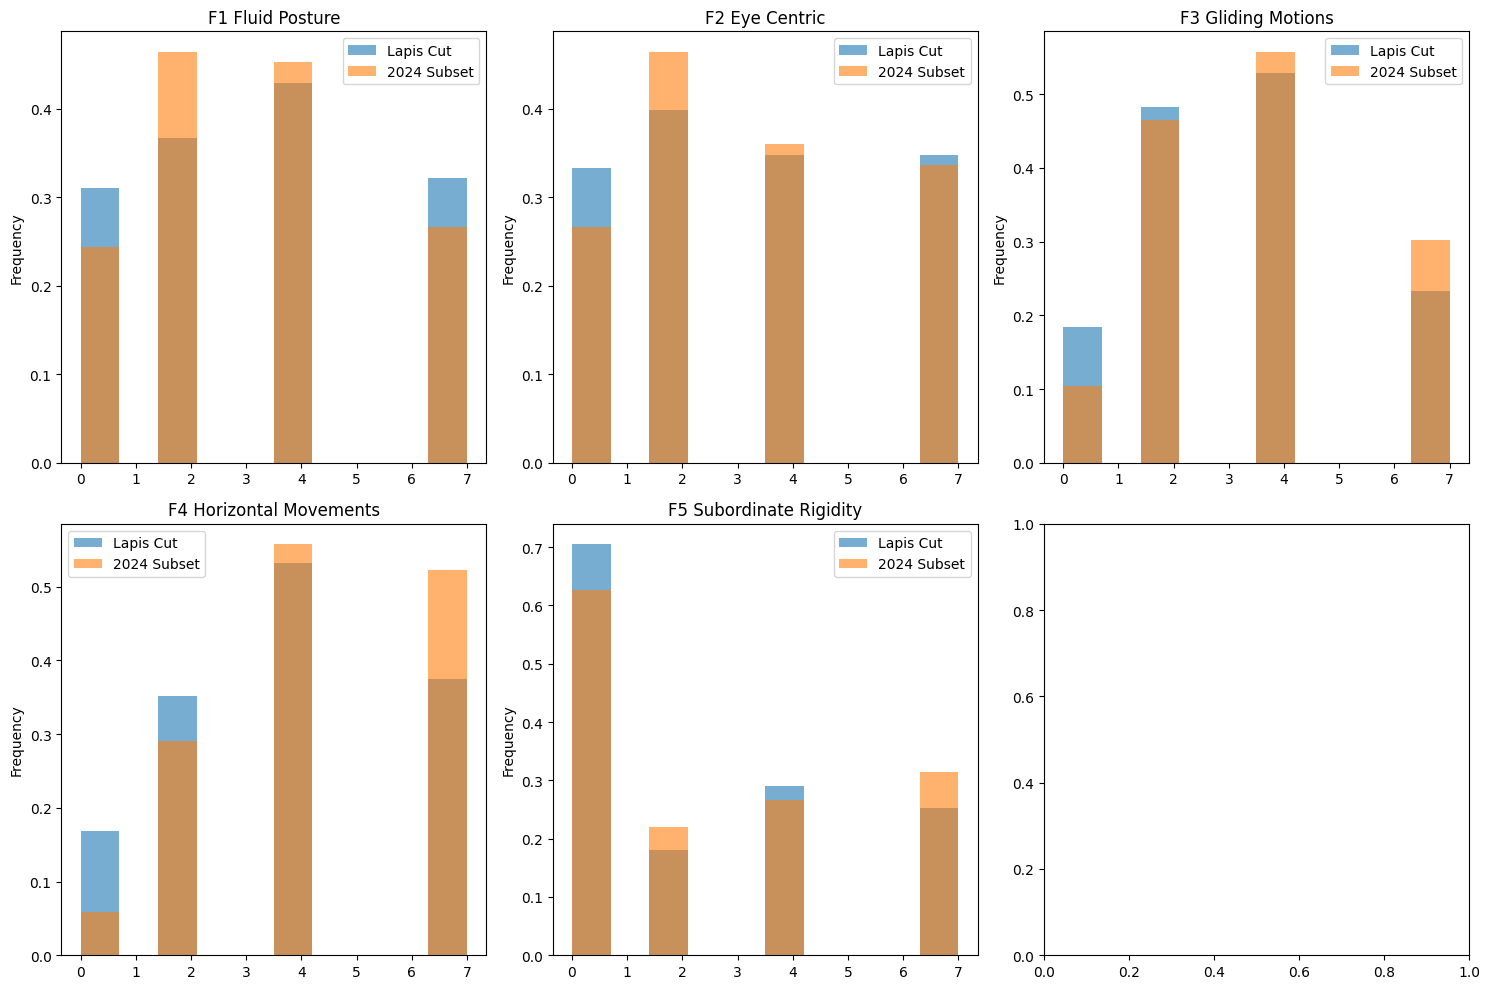

In [102]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(lapis_df.loc[:,'F1 Fluid Posture':'F5 Subordinate Rigidity'].columns):
    ax = axes[i]
    lapis_df[column].plot(kind='hist', density=True, alpha=0.6, label='Lapis Cut', ax=ax)
    lapis_2024[column].plot(kind='hist', density=True, alpha=0.6, label='2024 Subset', ax=ax)
    ax.set_title(column)
    ax.legend()

plt.tight_layout()
plt.show()

This looks highly similar to the Full Data case as well, almost exactly the same pattern

### Pe Signals <a id="PeLC"></a>

In [101]:
lapis_2024.loc[:,'PF1 Restless Momentum':'PF5 Alert Perk Ups'].describe()

,PF1 Restless Momentum,PF2 Toggling Eyes,PF3 Body Swaying,PF4 Casual Hands,PF5 Alert Perk Ups
count,123.000000,123.000000,123.000000,123.000000,123.000000
mean,2.731707,4.682927,4.081301,4.634146,3.430894
std,1.811046,2.001299,2.066888,2.218655,2.279924
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,4.000000,2.000000,4.000000,2.000000
50%,2.000000,4.000000,4.000000,4.000000,4.000000
75%,4.000000,7.000000,7.000000,7.000000,4.000000
max,7.000000,7.000000,7.000000,7.000000,7.000000


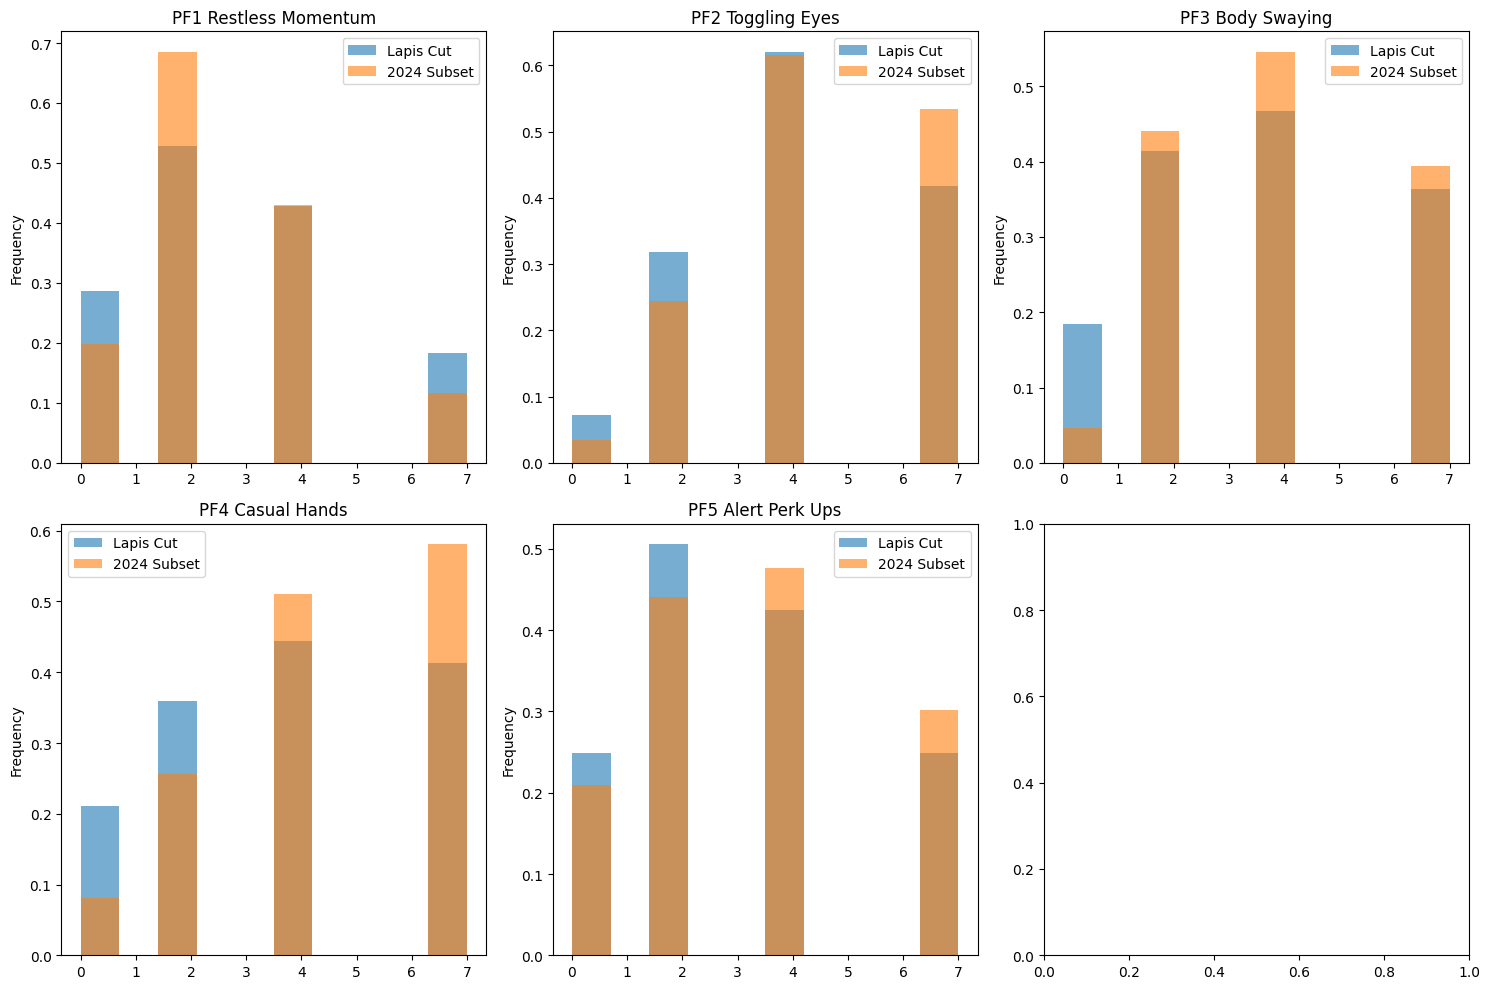

In [103]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(lapis_df.loc[:,'PF1 Restless Momentum':'PF5 Alert Perk Ups'].columns):
    ax = axes[i]
    lapis_df[column].plot(kind='hist', density=True, alpha=0.6, label='Lapis Cut', ax=ax)
    lapis_2024[column].plot(kind='hist', density=True, alpha=0.6, label='2024 Subset', ax=ax)
    ax.set_title(column)
    ax.legend()

plt.tight_layout()
plt.show()

Yet again almost entirely similar changes and patterns to the full data case

### Je Signals <a id="JeLC"></a>

In [104]:
lapis_2024.loc[:,'PR1 Head Pushes':'PR5 Projecting Hands'].describe()

,PR1 Head Pushes,PR2 Head Shakes,PR3 Shoulder Shrugs,PR4 Fluent Articulation,PR5 Projecting Hands
count,123.000000,123.000000,123.000000,123.000000,123.000000
mean,4.097561,3.569106,2.252033,4.528455,4.829268
std,2.341411,2.115831,1.642636,2.097325,2.160401
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000,4.000000,4.000000
50%,4.000000,4.000000,2.000000,4.000000,4.000000
75%,7.000000,4.000000,4.000000,7.000000,7.000000
max,7.000000,7.000000,7.000000,7.000000,7.000000


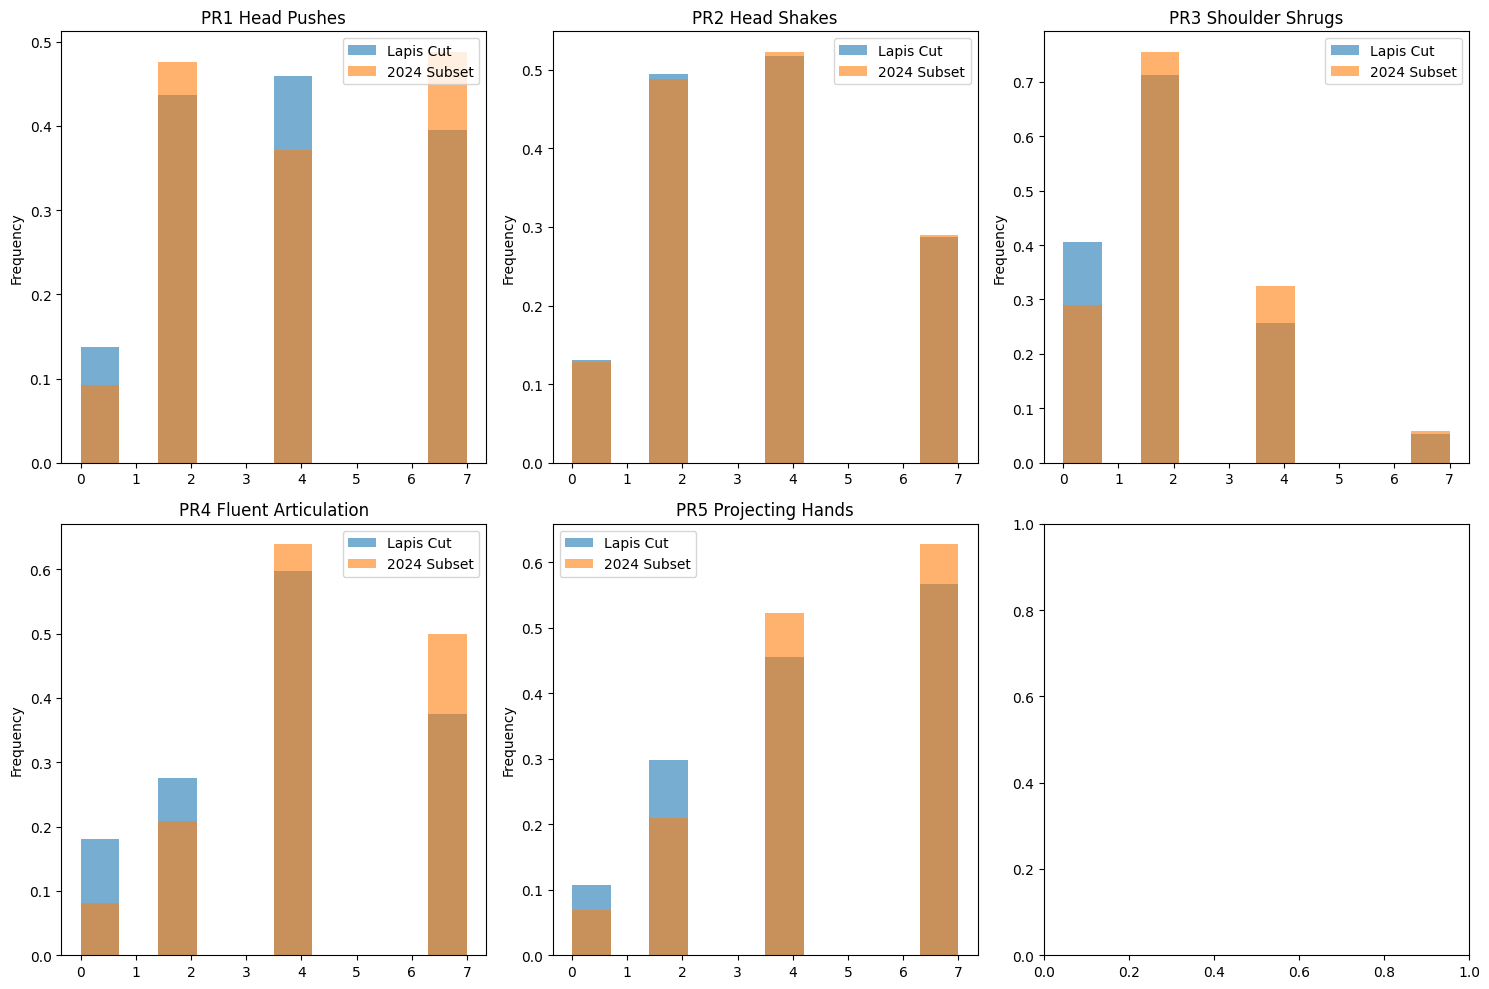

In [105]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(lapis_df.loc[:,'PR1 Head Pushes':'PR5 Projecting Hands'].columns):
    ax = axes[i]
    lapis_df[column].plot(kind='hist', density=True, alpha=0.6, label='Lapis Cut', ax=ax)
    lapis_2024[column].plot(kind='hist', density=True, alpha=0.6, label='2024 Subset', ax=ax)
    ax.set_title(column)
    ax.legend()

plt.tight_layout()
plt.show()

Yet again we see nearly the same patterns as in the full data

### Ji Signals <a id="JiLC"></a>

In [106]:
lapis_2024.loc[:,'RR1 Poised Receding':'RR5 Meticulous Hands'].describe()

,RR1 Poised Receding,RR2 Disengaging Eyes,RR3 Exerted Pushes,RR4 Momentum Halting,RR5 Meticulous Hands
count,123.000000,123.000000,123.000000,123.000000,123.000000
mean,3.138211,3.243902,2.032520,2.154472,4.056911
std,2.305820,2.155213,1.634339,1.674459,2.226152
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,0.000000,2.000000,2.000000
50%,2.000000,4.000000,2.000000,2.000000,4.000000
75%,4.000000,4.000000,4.000000,3.000000,7.000000
max,7.000000,7.000000,7.000000,7.000000,7.000000


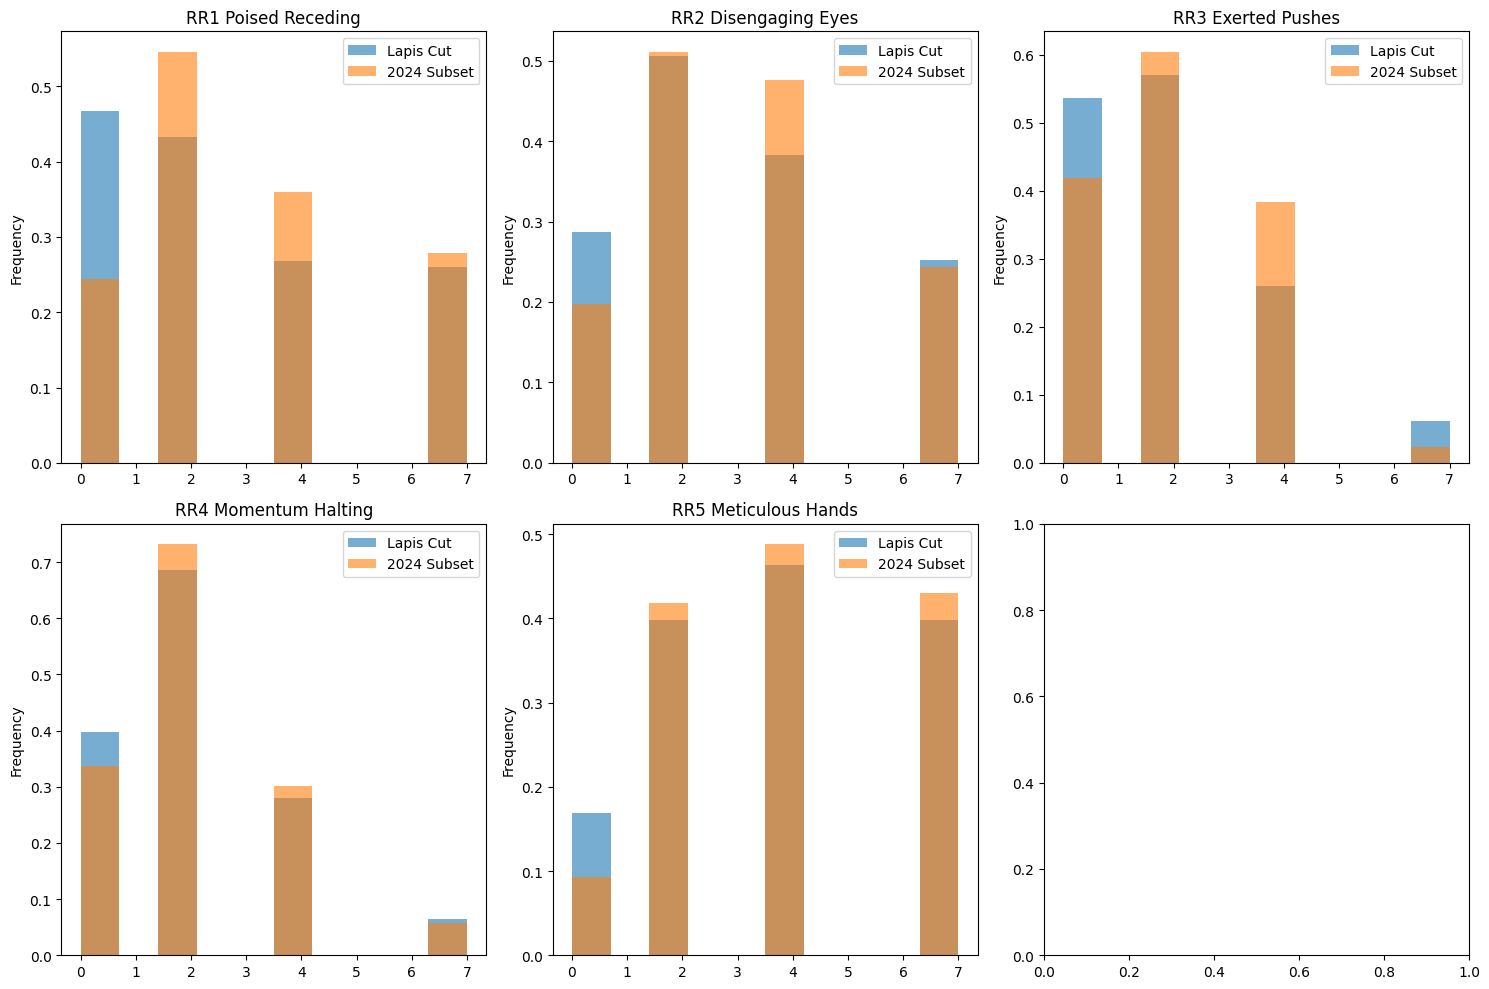

In [107]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(lapis_df.loc[:,'RR1 Poised Receding':'RR5 Meticulous Hands'].columns):
    ax = axes[i]
    lapis_df[column].plot(kind='hist', density=True, alpha=0.6, label='Lapis Cut', ax=ax)
    lapis_2024[column].plot(kind='hist', density=True, alpha=0.6, label='2024 Subset', ax=ax)
    ax.set_title(column)
    ax.legend()

plt.tight_layout()
plt.show()

It's virtually the same as in the full data

### Measured Signals <a id="MeasuredLC"></a>

In [108]:
lapis_2024.loc[:,'MS1 Lax Nasolabial Area':'MS9 Puppeteer Hands'].describe()

,MS1 Lax Nasolabial Area,MS2 Horizontal Curtain Smiles,MS3 Two Point Pulling,MS4 Symmetrical Lips,MS5 Emotional Neutralization,MS6 Coordinated Movements,MS7 Parabolic Velocity,MS8 Laryngeal Faint Voice,MS9 Puppeteer Hands
count,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.00000
mean,2.162602,3.585366,3.243902,3.040650,2.585366,3.373984,3.707317,2.642276,1.96748
std,2.233772,2.691598,2.584130,2.263026,2.142187,2.288239,2.534133,2.630621,2.12300
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,0.000000,1.000000,0.000000,2.000000,1.000000,2.000000,2.000000,0.000000,0.00000
50%,2.000000,4.000000,4.000000,4.000000,2.000000,2.000000,4.000000,2.000000,2.00000
75%,4.000000,7.000000,4.000000,4.000000,4.000000,4.000000,7.000000,4.000000,4.00000
max,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.00000


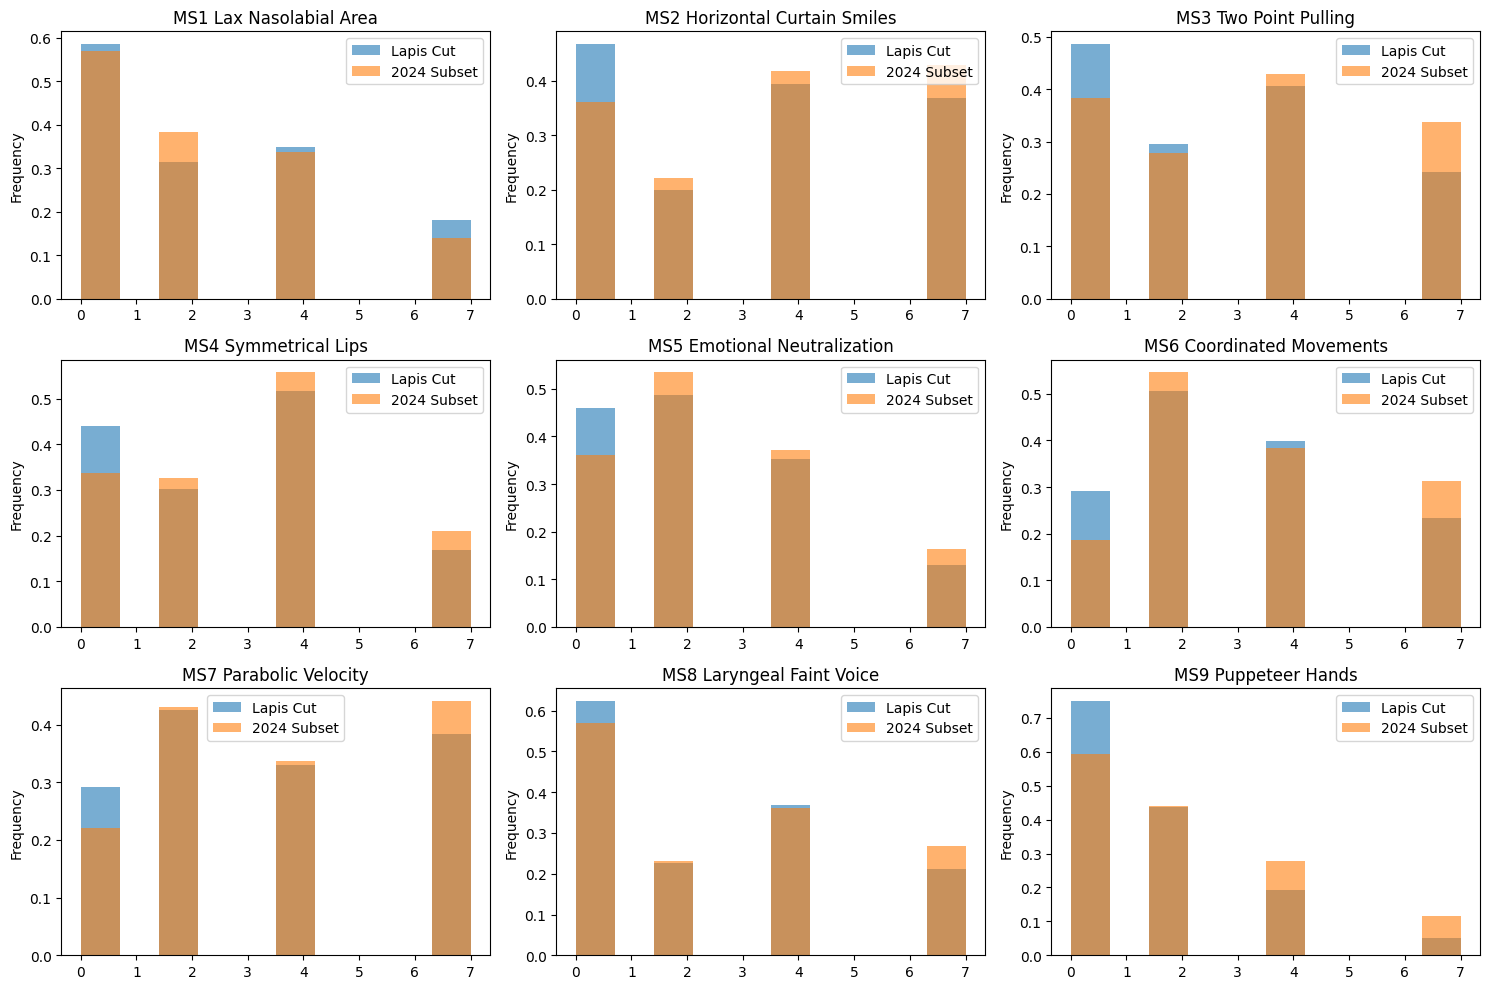

In [109]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, column in enumerate(lapis_df.loc[:,'MS1 Lax Nasolabial Area':'MS9 Puppeteer Hands'].columns):
    ax = axes[i]
    lapis_df[column].plot(kind='hist', density=True, alpha=0.6, label='Lapis Cut', ax=ax)
    lapis_2024[column].plot(kind='hist', density=True, alpha=0.6, label='2024 Subset', ax=ax)
    ax.set_title(column)
    ax.legend()

plt.tight_layout()
plt.show()

Again, I'm not really seeing a significant difference here. With that being said, I don't think I'm going to bother going through any more of these, you can probably see now why I thought so many weren't worth examining to begin with.

Overall, the results we got from this notebook are quite striking and noteworthy:

- the mean difference in Vultology report signal sums from the full data compared to the 2024 samples is 23 points, which is roughly 3 high signals, 6 medium signals or 12 low signals per report on average
- accordingly, the central tendency of each signals (the mean/median of its markings per report) nearly universally increased, with a particularly strong pattern being that 0 was a much rarer marking for many individual signal (for some of them 0 was drastically less frequent, and for some only by a small amount)
- in spite of the central tendency increasing for essentially every distribution, the shape parameters of the continuous distributions that we studied did not change significantly (considering other central moments, near fitting distributions, etc.), excluding the central tendency
- in 2024, there was a particularly concentration of Se leads, a notably larger concentration of Fe leads, and a notable downtick in all of the Te conductor types (especially SiTe which had almost none), I'm not sure if that pattern is significant or whether it was just happenstance due to the interests of which celebrities happened to be typed this year, whether those trends will continue is something we'll have the opportunity to observe with more data
- proportionally we are saying far fewer i--- devs in 2024 (these used to be the most common but they are only in 3rd place in the 2024 data), we're also naturally seeing more samples with complex developments, this is all explainable by the increasing sums of signals in reports, because with more signals marked, more complex developmenets will occur more frequently as a direct result, thus the grant stack assumptions that originally looked to be supported by Vultology might legitimately no longer hold, but we'll have to see if this trend continues, especially in a non-celebrity context

All of these patterns seem like the obvious result of Vultologists paying more attention to creating complete reports even if it means markings signals that are on the opposite side of the dichotomy of a person's Vultology type, and these signals may have been somewhat neglected before (at least to a greater extent than they tend to be recently). And this goes to reinforce how dependent these statistics are on real Vultological practices and procedures.

These differences in the data over time make me think that we should repeat this statistical project on a somewhat regular basis (perhaps yearly or biyearly) in order to check if the previous statistical conclusions still hold. We might be able to automate these statistics as well and look at more cross-sections of the data than just 2024, since we might want to actually observe where the inflection points of various statistical changes are occuring, but all of that is to come.